In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange
from astropy.cosmology import Planck18
import pyccl as ccl

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.0 #.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


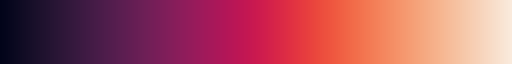

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12267/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_12267/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


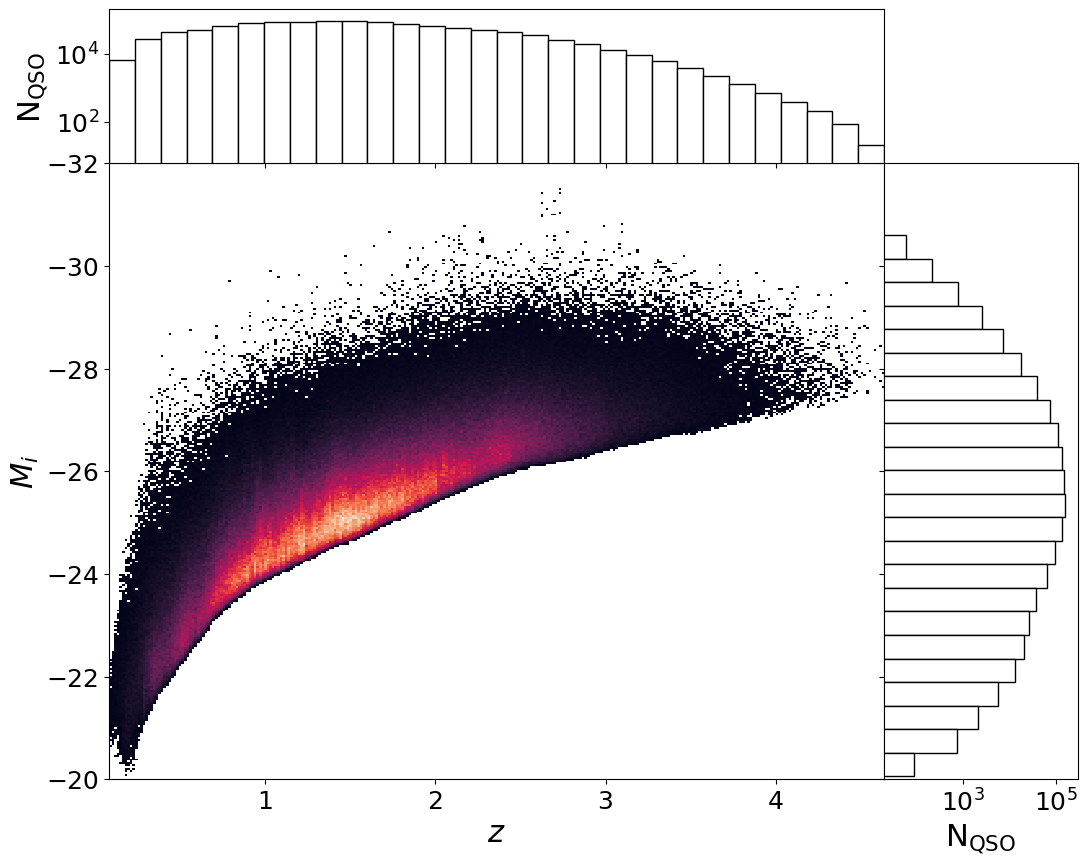

In [10]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in joint L threshold and z bins
## $w_p(r_p)$

In [11]:
# Create the bins array
rmin = 30 #1 #30 #30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 180 #200 # 180 #80 #80+delta_max*offset # 200
nbins = 30 #14 #30 #10 #int((rmax-rmin)/offset) #20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins)), np.diff(np.log10(rbins))

# # Create the bins array
# rmin = 1 #30 #30-delta_min*offset # 0.1 # start higher # 1.4 # 30
# rmax = 200 # 180 #80 #80+delta_max*offset # 200
# nbins = 14 #30 #10 #int((rmax-rmin)/offset) #20 + int(delta_min+delta_max) #90 #20
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) #np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'log' #'linear'
# rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins)), np.diff(np.log10(rbins))

(array([ 30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,
         85.,  90.,  95., 100., 105., 110., 115., 120., 125., 130., 135.,
        140., 145., 150., 155., 160., 165., 170., 175., 180.]),
 array([ 32.5,  37.5,  42.5,  47.5,  52.5,  57.5,  62.5,  67.5,  72.5,
         77.5,  82.5,  87.5,  92.5,  97.5, 102.5, 107.5, 112.5, 117.5,
        122.5, 127.5, 132.5, 137.5, 142.5, 147.5, 152.5, 157.5, 162.5,
        167.5, 172.5, 177.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]),
 array([0.06694679, 0.05799195, 0.05115252, 0.04575749, 0.04139269,
        0.03778856, 0.03476211, 0.03218468, 0.02996322, 0.02802872,
        0.02632894, 0.02482358, 0.0234811 , 0.02227639, 0.0211893 ,
        0.02020339, 0.01930516, 0.01848341, 0.01772877, 0.01703334,
        0.01639042, 0.01579427, 0.01523997, 0.01472326, 0.01424044,
        0.01378828, 0.01336396, 0.01296498, 0.01258913, 0.01223446]))

In [12]:
pimax = 80 # 40 # 5000.0 # 40.0

In [13]:
zbin_array = [0.0,1.0,2.0,3.0,4.6]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

In [14]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

## Pick cosmology

In [15]:
cosmo = 'Planck' #'Planck'

In [16]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12267/3289205115.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]),
/tmp/ipykernel_12267/3289205115.py:60: SyntaxWarning: invalid escape sequence '\l'
  ax1.legend(loc = 'center right', bbox_to_anchor = (-0.15, 0.5), title = '$M_i\leq{}$'.format(L_bins[i]), title_fontsize = 18)
/tmp/ipykernel_12267/3289205115.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


0.7606791583065621
Pixels masked by MC but not already by selfunc: 926
G20.0_zmin0.0zmax1.0_Lmax-20.0: 0.31              138599 vs 200785


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.7572178281423043
Pixels masked by MC but not already by selfunc: 2094
G20.0_zmin1.0zmax2.0_Lmax-20.0: 0.28              264696 vs 369335


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.9056881062623002
Pixels masked by MC but not already by selfunc: 544
G20.0_zmin2.0zmax3.0_Lmax-27.0: 0.34              63795 vs 96220


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.8660172206218933
Pixels masked by MC but not already by selfunc: 78
G20.0_zmin3.0zmax4.6_Lmax-27.0: 0.22              15855 vs 20379


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


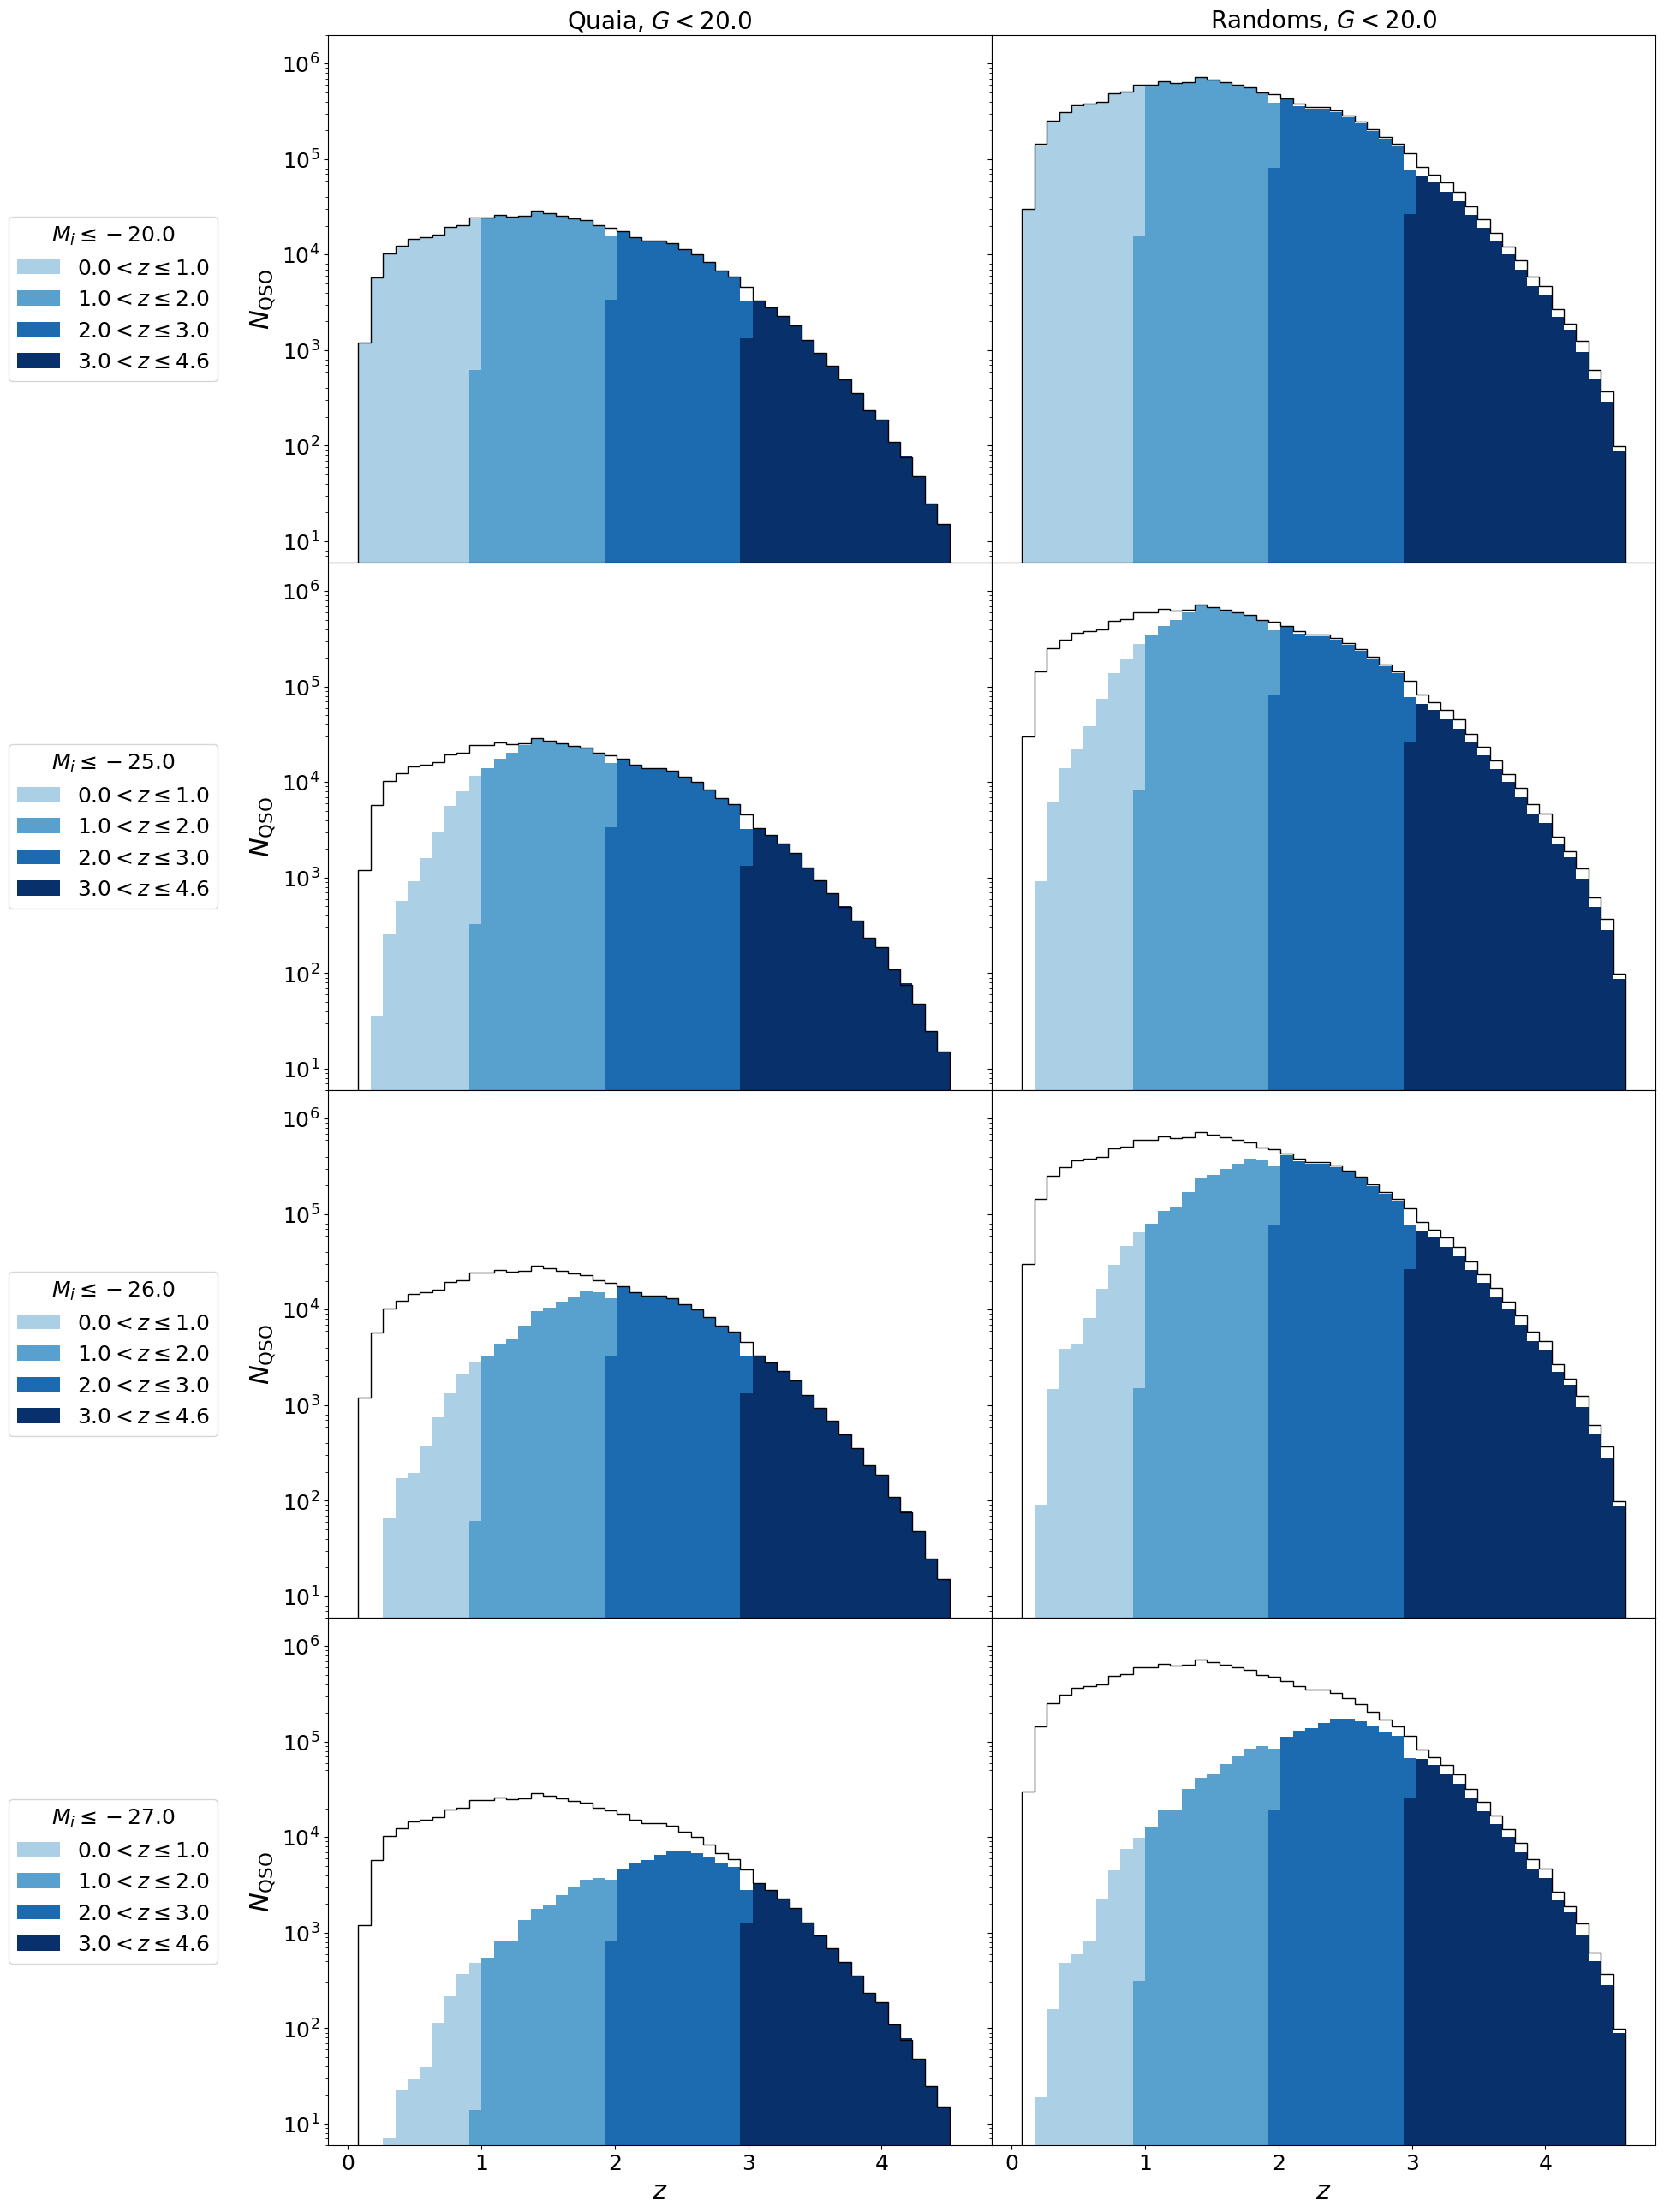

In [17]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = {L: [] for L in L_bins}, {L: [] for L in L_bins}
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)

N_q = {L: [] for L in L_bins}
for i in range(len(L_bins)):
    
    ax1 = fig.add_subplot(gs[i*2])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

    # plot randoms  
    ax2 = fig.add_subplot(gs[i*2+1])
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')
        
    for j in range(len(zbin_array)-1):
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                             bins = [zbin_array, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])
        
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]), 
                 bins = bins, color = cmap_blue[j])
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(i),
                 bins = bins, color = cmap_blue[j])

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, Om0 = Planck18.Om0, #Om0[cosmo], 
                                                      h = Planck18.h, rbins = rbins, nbins = nbins, pimax = pimax)
        wp[L_bins[i]].append(wp_datahi_zbin0)
        rpavg[L_bins[i]].append(rpavg_datahi_zbin0)

        N_q[L_bins[i]].append(len(tab_datahi_mask_zbin0))

    ax1.set_xlabel('$z$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,2e6)
    ax1.legend(loc = 'center right', bbox_to_anchor = (-0.15, 0.5), title = '$M_i\leq{}$'.format(L_bins[i]), title_fontsize = 18)
    ax1.set_ylabel('$N_\mathrm{QSO}$')

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,2e6)
    ax2.set_yticklabels([])
    
    if i == 0:
        ax1.set_title('Quaia, $G<{}$'.format(G_hi))
        ax2.set_title('Randoms, $G<{}$'.format(G_hi))
        
    if i < 3:
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])
        
plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [34]:
N = 50 #24 #40 #20 #65 #50 #30 #15 #45 #85 #25 #10
ra_bins = np.linspace(0, 360, N+1)
for i in range(N): #-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50]
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50]
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50]
[ 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32

## Compute $w_p(r_p)$ in each jackknife bin

In [35]:
wp_jackknife = {Lbin: [] for Lbin in L_bins}

for k in range(len(L_bins)):

    for j in range(len(zbin_array)-1):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, k], True, ['z', 'L'], 
                                                                                             bins = [zbin_array, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])

        wp_jackknife[L_bins[k]].append([])
        
        for i in trange(N): #len(ra_bins)-1):

            jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
            jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

            wp_jackknife[L_bins[k]][j].append(quaia.wp_rp(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                                          nthreads = nthreads, Om0 = Planck18.Om0, h = Planck18.h, rbins = rbins, nbins = nbins, 
                                                          pimax = pimax)[0])

0.7606791583065621
Pixels masked by MC but not already by selfunc: 926
G20.0_zmin0.0zmax1.0_Lmax-20.0: 0.31              138599 vs 200785


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [13:36<00:00, 16.33s/it]


0.7572178281423043
Pixels masked by MC but not already by selfunc: 2094
G20.0_zmin1.0zmax2.0_Lmax-20.0: 0.28              264696 vs 369335


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [23:32<00:00, 28.24s/it]


0.7346083175107806
Pixels masked by MC but not already by selfunc: 1127
G20.0_zmin2.0zmax3.0_Lmax-20.0: 0.26              122259 vs 165277


...

  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [01:46<00:00,  2.13s/it]


0.9056881062623002
Pixels masked by MC but not already by selfunc: 544
G20.0_zmin2.0zmax3.0_Lmax-27.0: 0.34              63795 vs 96220


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [04:37<00:00,  5.56s/it]


0.8660172206218933
Pixels masked by MC but not already by selfunc: 78
G20.0_zmin3.0zmax4.6_Lmax-27.0: 0.22              15855 vs 20379


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [01:04<00:00,  1.29s/it]


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [36]:
C = {Lbin: [] for Lbin in L_bins}

for i in range(len(L_bins)):
    
    for j in range(len(zbin_array)-1):

        wp_mean = np.nanmean(wp_jackknife[L_bins[i]][j], axis = 0)  # is it ok to ignore nan values?
        delta = wp_jackknife[L_bins[i]][j]-wp_mean
        C[L_bins[i]].append((N-1)/N*(delta.T @ delta))

## Save the full covariance matrix

In [37]:
for i in range(len(L_bins)):

    for j in range(len(zbin_array)-1):
    
        np.save('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask'.format(G_hi, rmin, rmax, nbins, pimax, 
                                                                                                                zbin_array[j], zbin_array[j+1], 
                                                                                                                L_bins[i], N, cosmo), C[L_bins[i]][j])

# Plot

In [38]:
offset = 0.3

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/3846085875.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(np.array(rpavg[L_bins[j]][i])+offset*j, wp[L_bins[j]][i], marker = 'o', label = '$M_i\leq{}$'.format(L_bins[j]),
/tmp/ipykernel_12267/3846085875.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


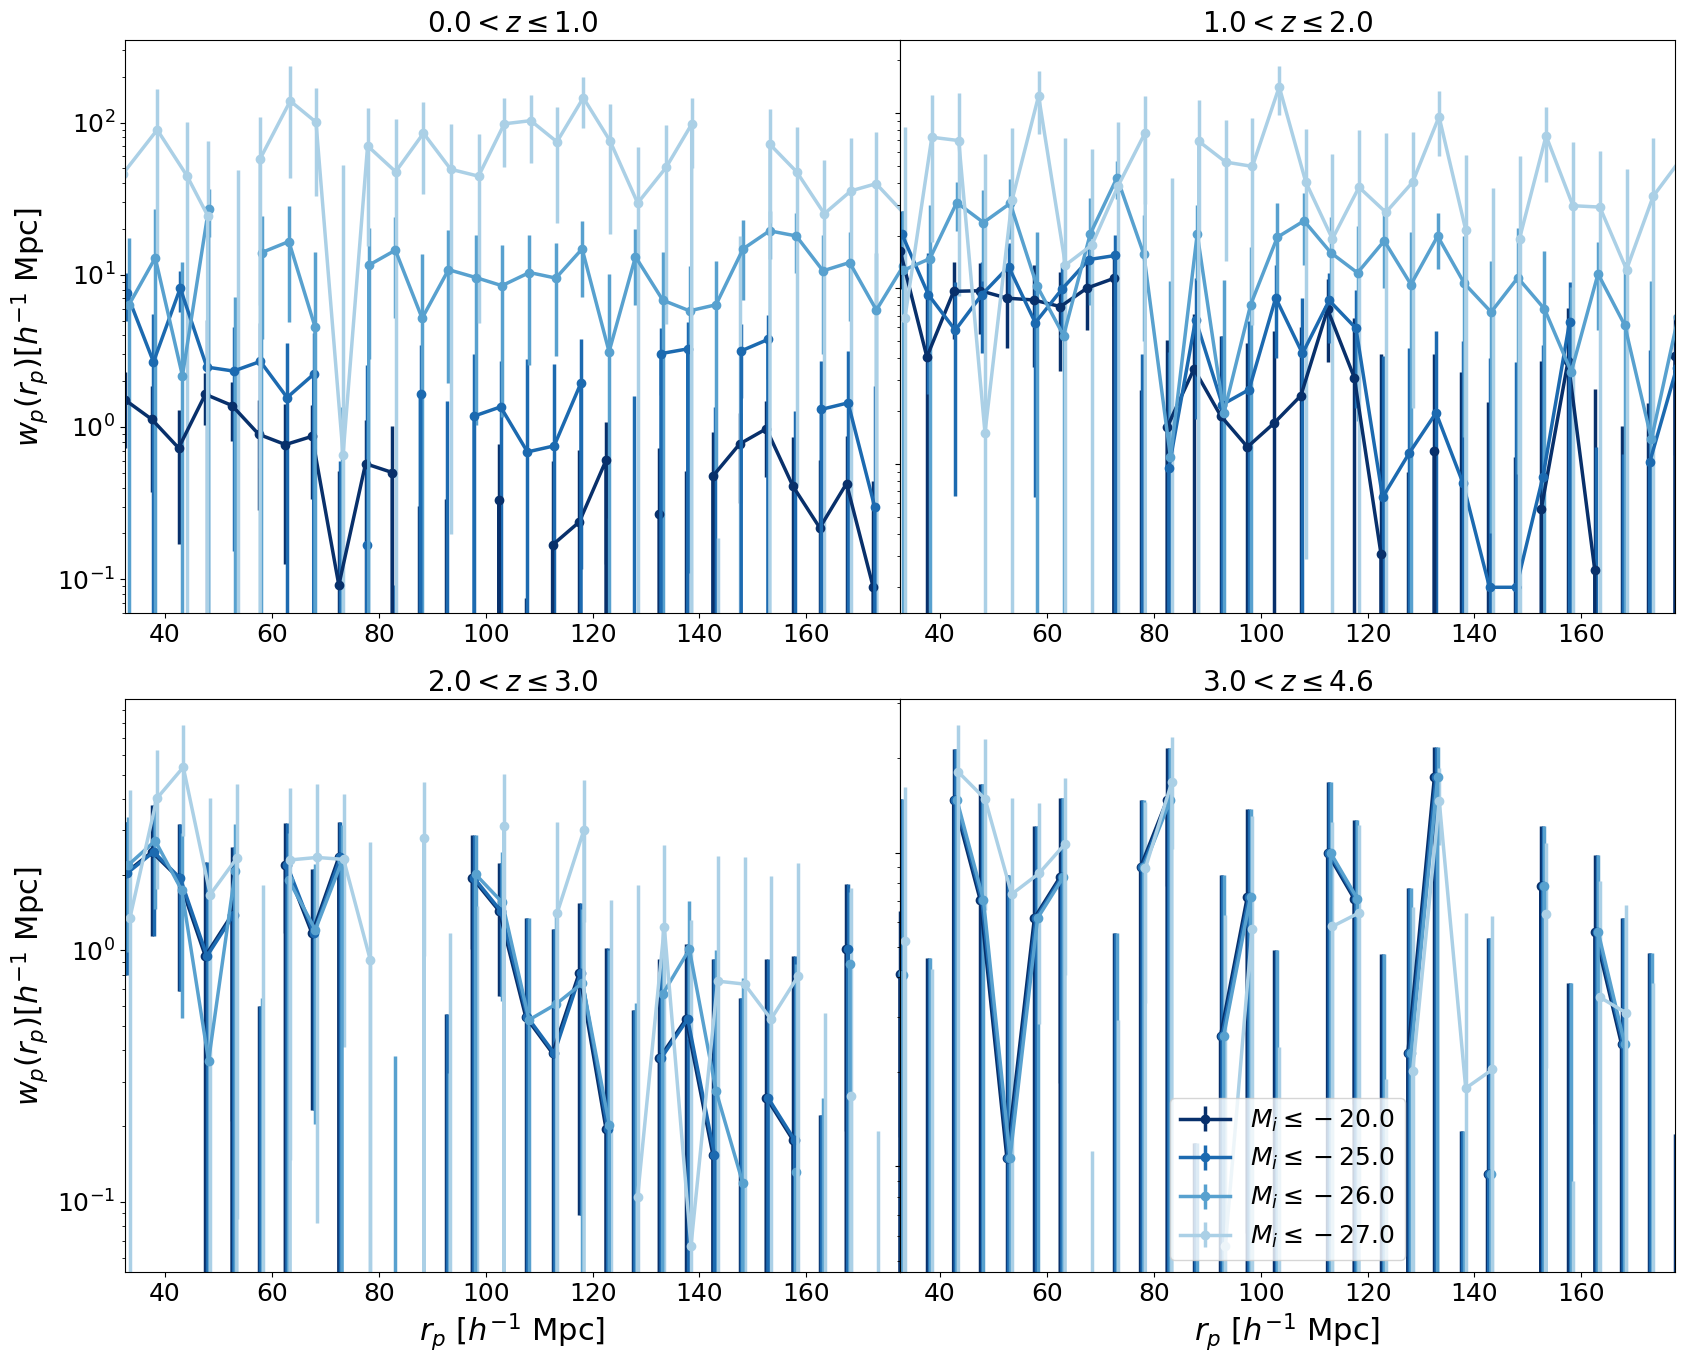

In [39]:
# plot!
r = quaia.recenter(rbins) #_chi2)

fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for i in range(len(zbin_array)-1):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(L_bins)):

        C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, 
                                                                                                                        pimax, zbin_array[i],
                                                                                                                        zbin_array[i+1], L_bins[j], N,
                                                                                                                        cosmo))
        ax1.errorbar(np.array(rpavg[L_bins[j]][i])+offset*j, wp[L_bins[j]][i], marker = 'o', label = '$M_i\leq{}$'.format(L_bins[j]), 
                 linewidth = 2.5, color = cmap_blue[::-1][j], yerr = np.sqrt(np.diag(C))) #np.sqrt(np.diag(C[zbin])))
    if i>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
    if i%2!=0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
        
ax1.legend()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/2468672147.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(np.array(rpavg[L_bins[j]][i])+offset*i, wp[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_12267/2468672147.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


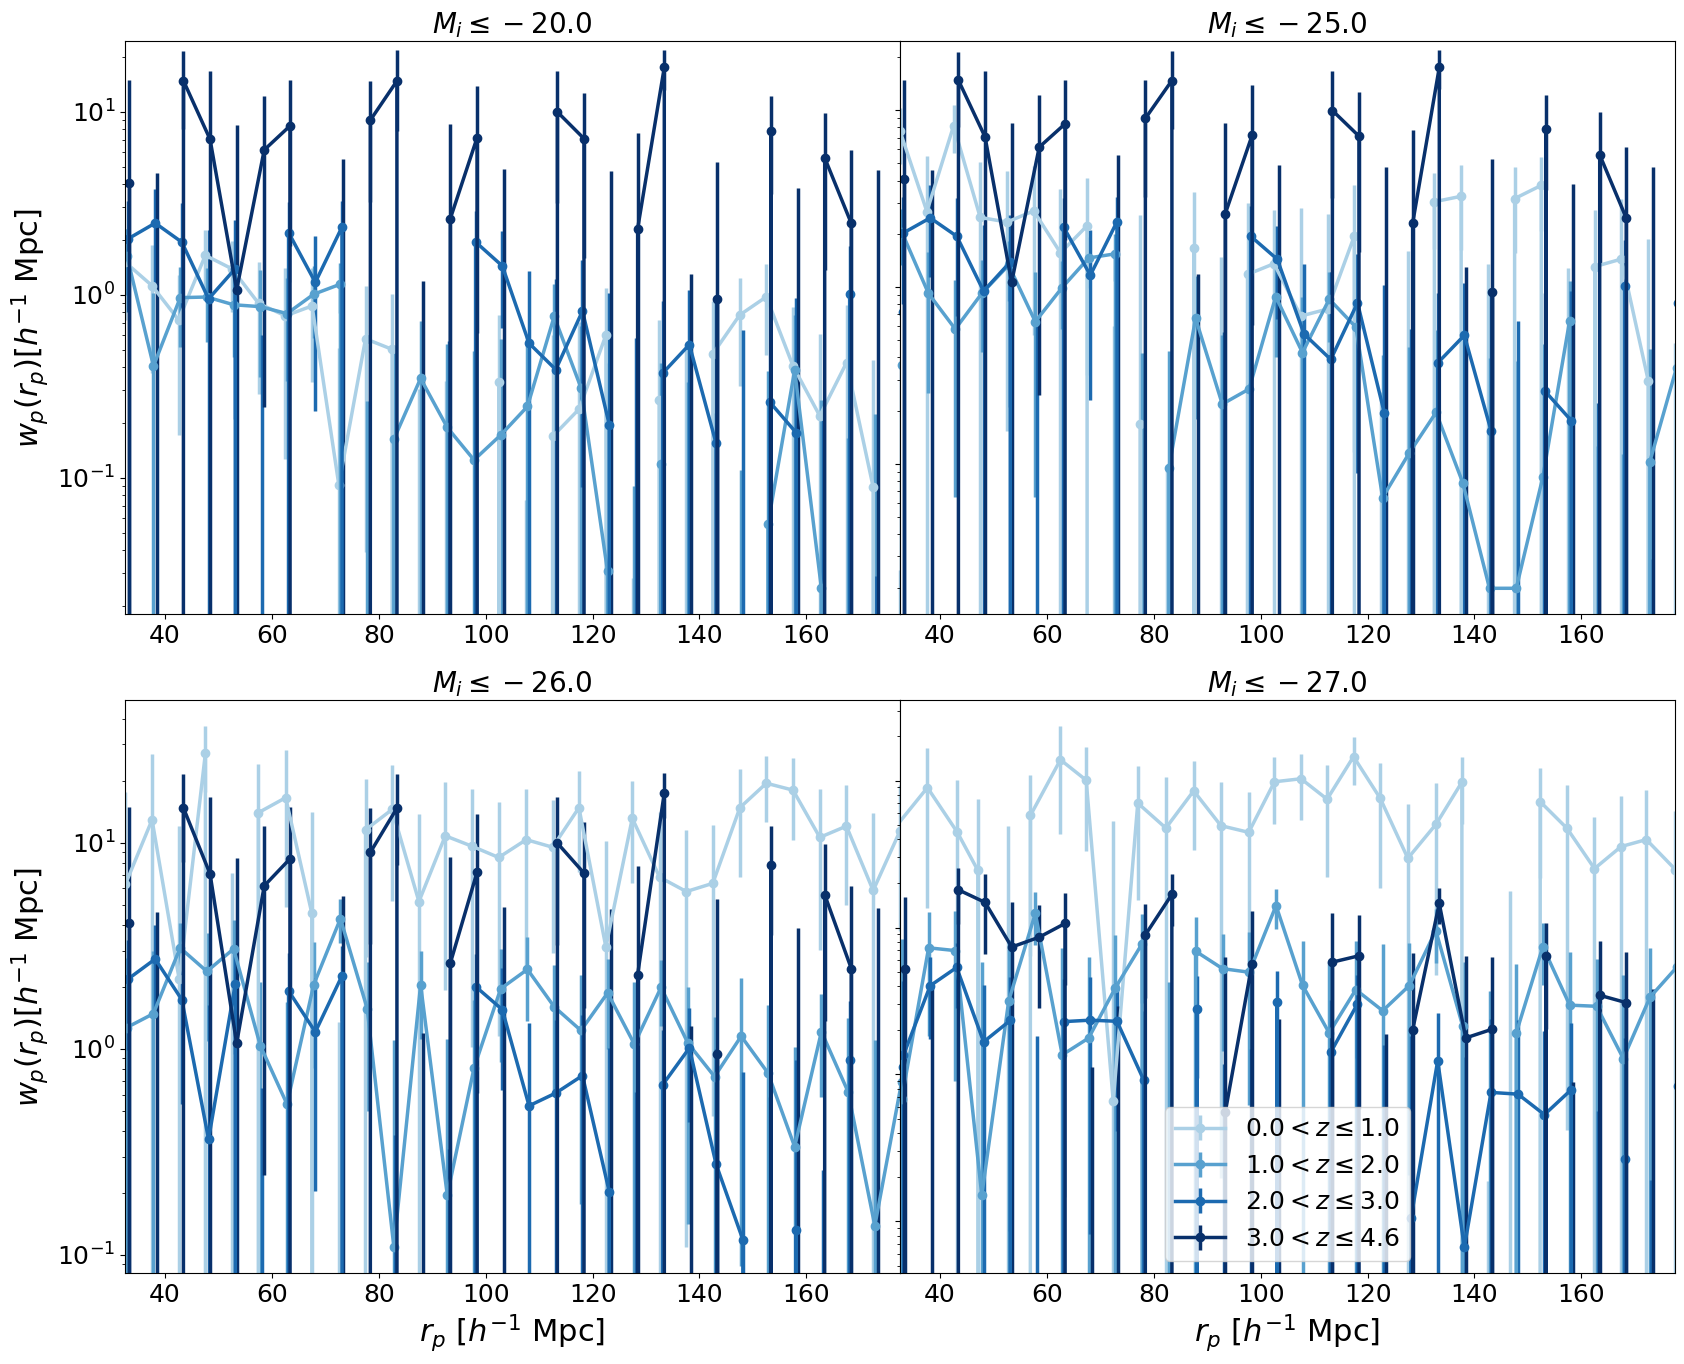

In [40]:
# plot!
r = quaia.recenter(rbins) #_chi2)

fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for j in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(zbin_array)-1):

        sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(np.array(rpavg[L_bins[j]][i])+offset*i, wp[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]), 
                 linewidth = 2.5, color = cmap_blue[i], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
        if j>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        if j%2!=0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
        ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))

ax1.legend()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/110899072.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(rpavg[L_bins[j]][i], wp[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_12267/110899072.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


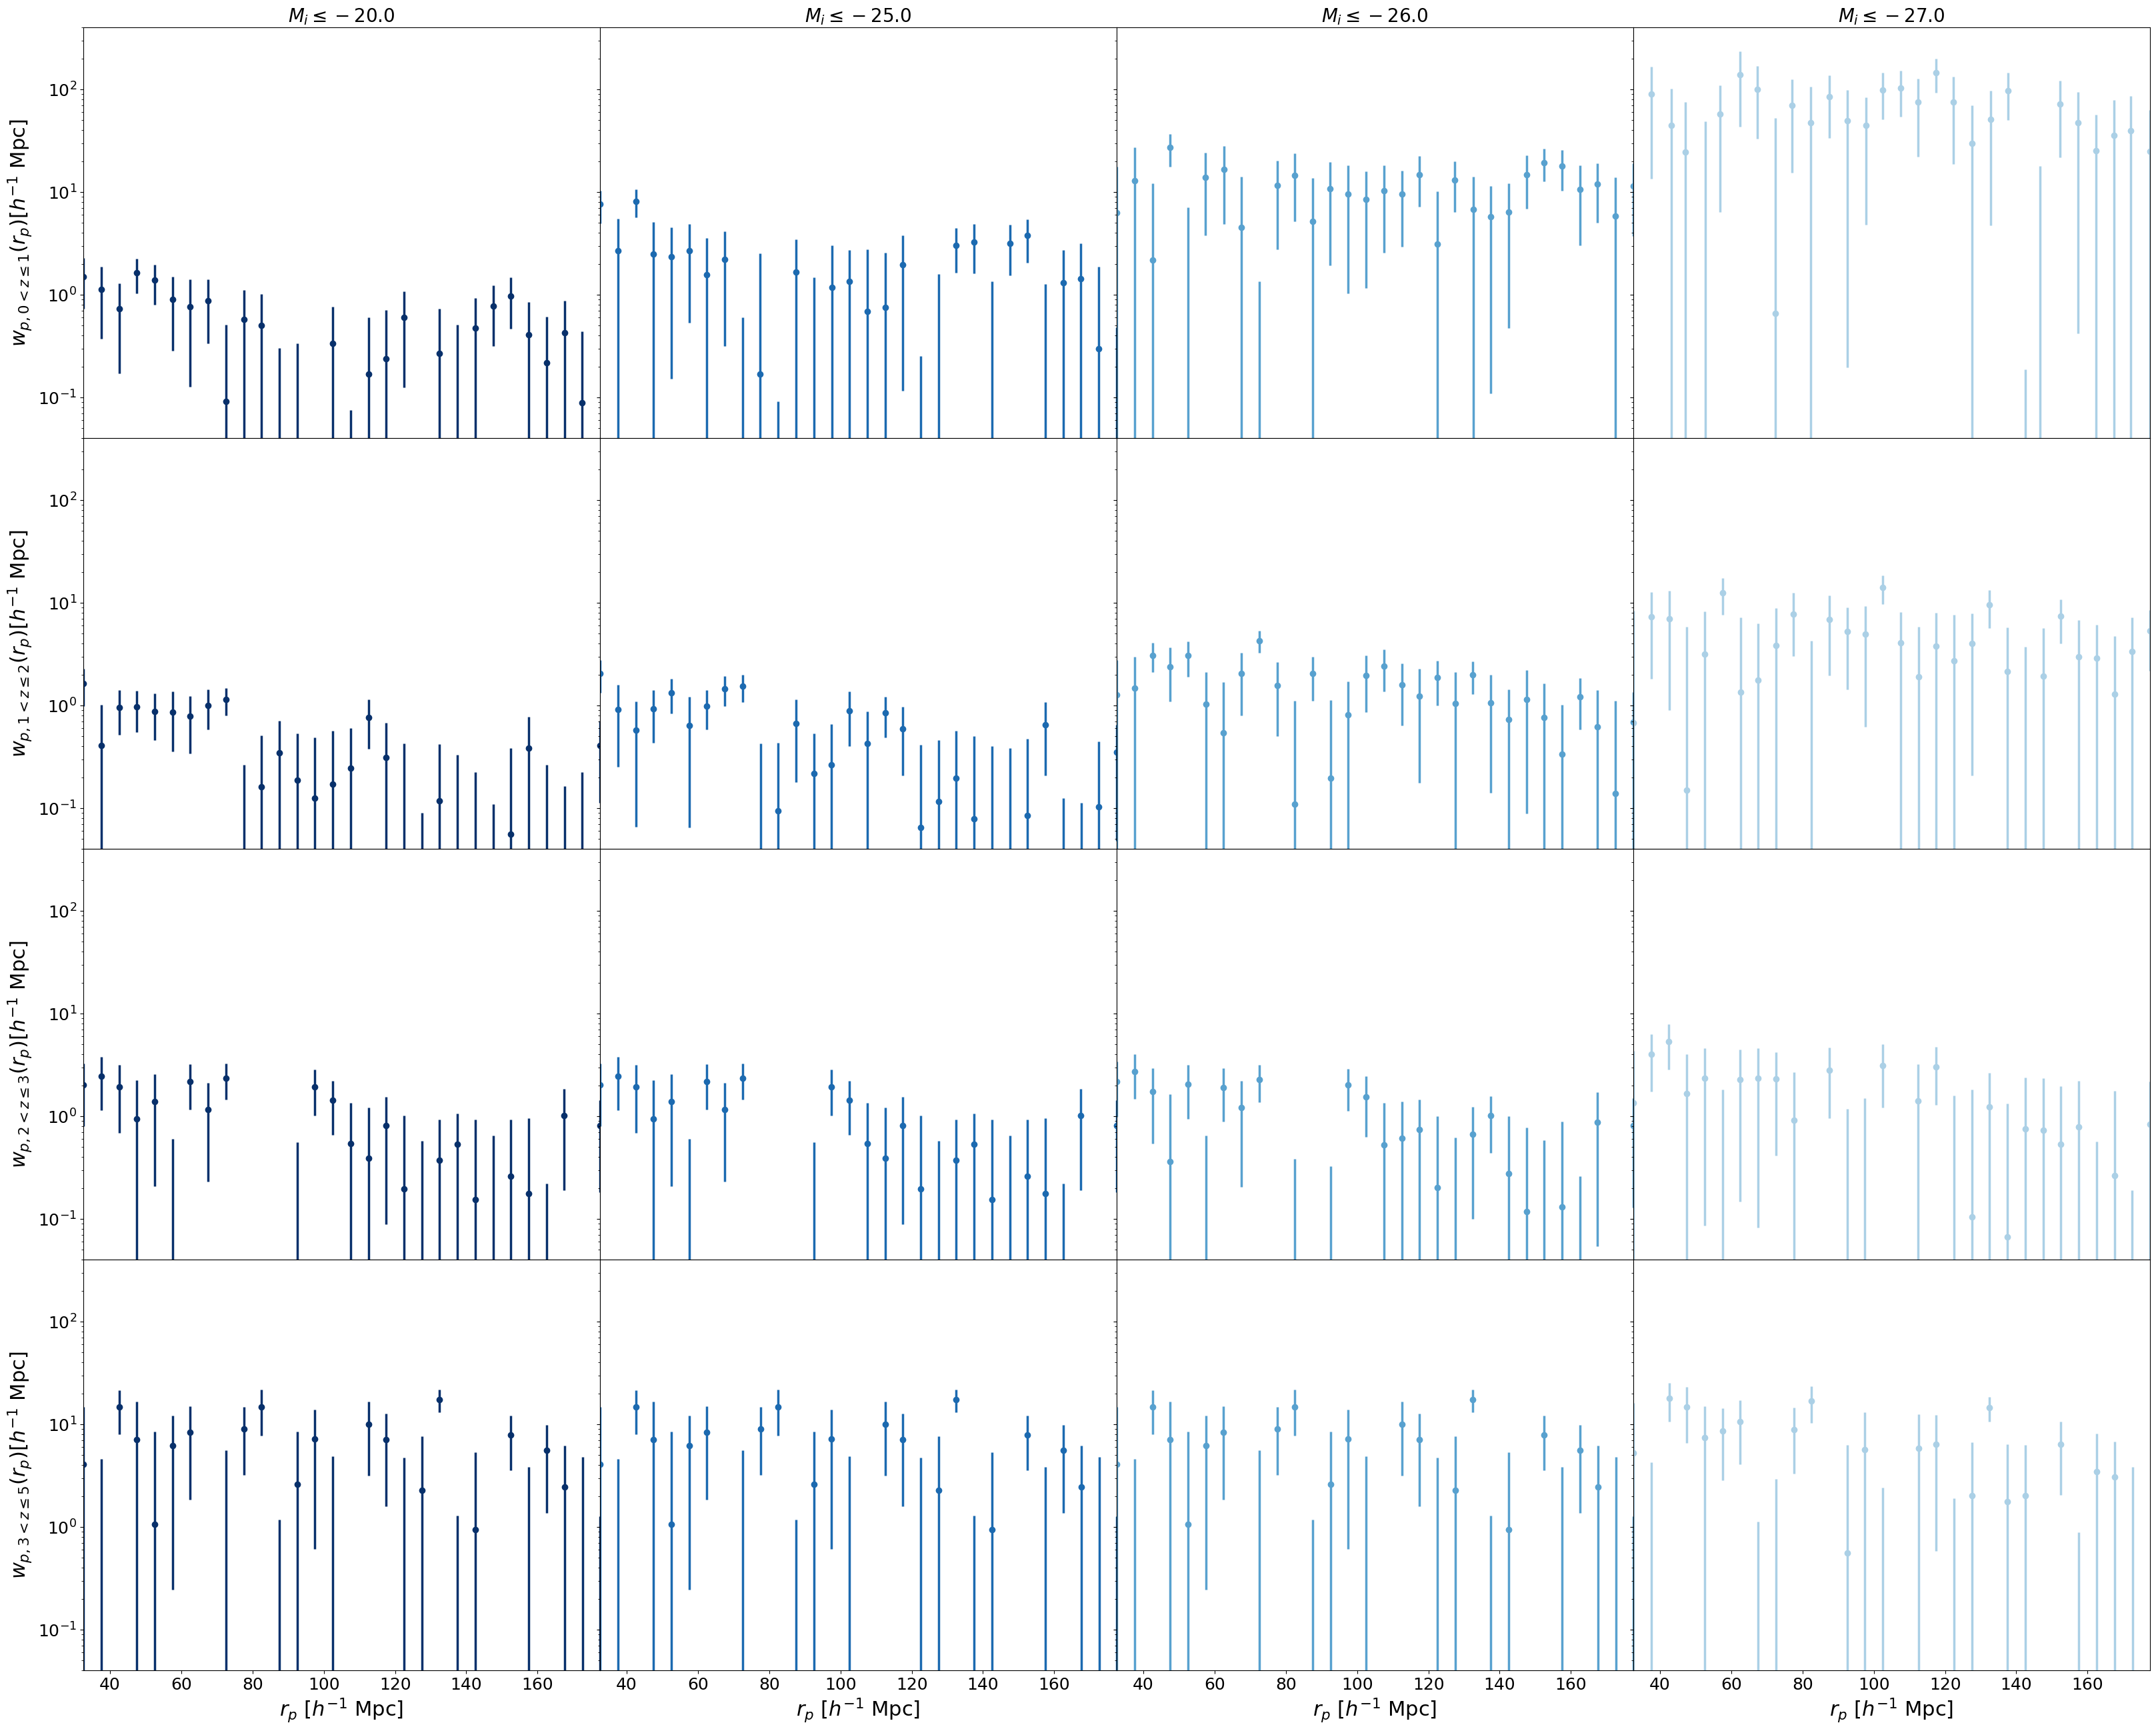

In [41]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)

for i in range(len(zbin_array)-1):
    
    for j in range(len(L_bins)):
    
        ax1 = fig.add_subplot(gs[i*4+j])

        sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(rpavg[L_bins[j]][i], wp[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
                 linewidth = 2.5, color = cmap_blue[::-1][j], yerr = sigma, linestyle = 'None')

        if i ==0:
            ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        ax1.set_ylim(4e-2, 4e2)
        if i > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if j==0:
            ax1.set_ylabel(r"$w_{{p,{:.0f}<z \leq{:.0f}}}(r_p) [h^{{-1}}$ Mpc]".format(zbin_array[i], zbin_array[i+1]))
        else:
            ax1.set_yticklabels([])

plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/511973927.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(rpavg[L_bins[j]][i], wp[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_12267/511973927.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


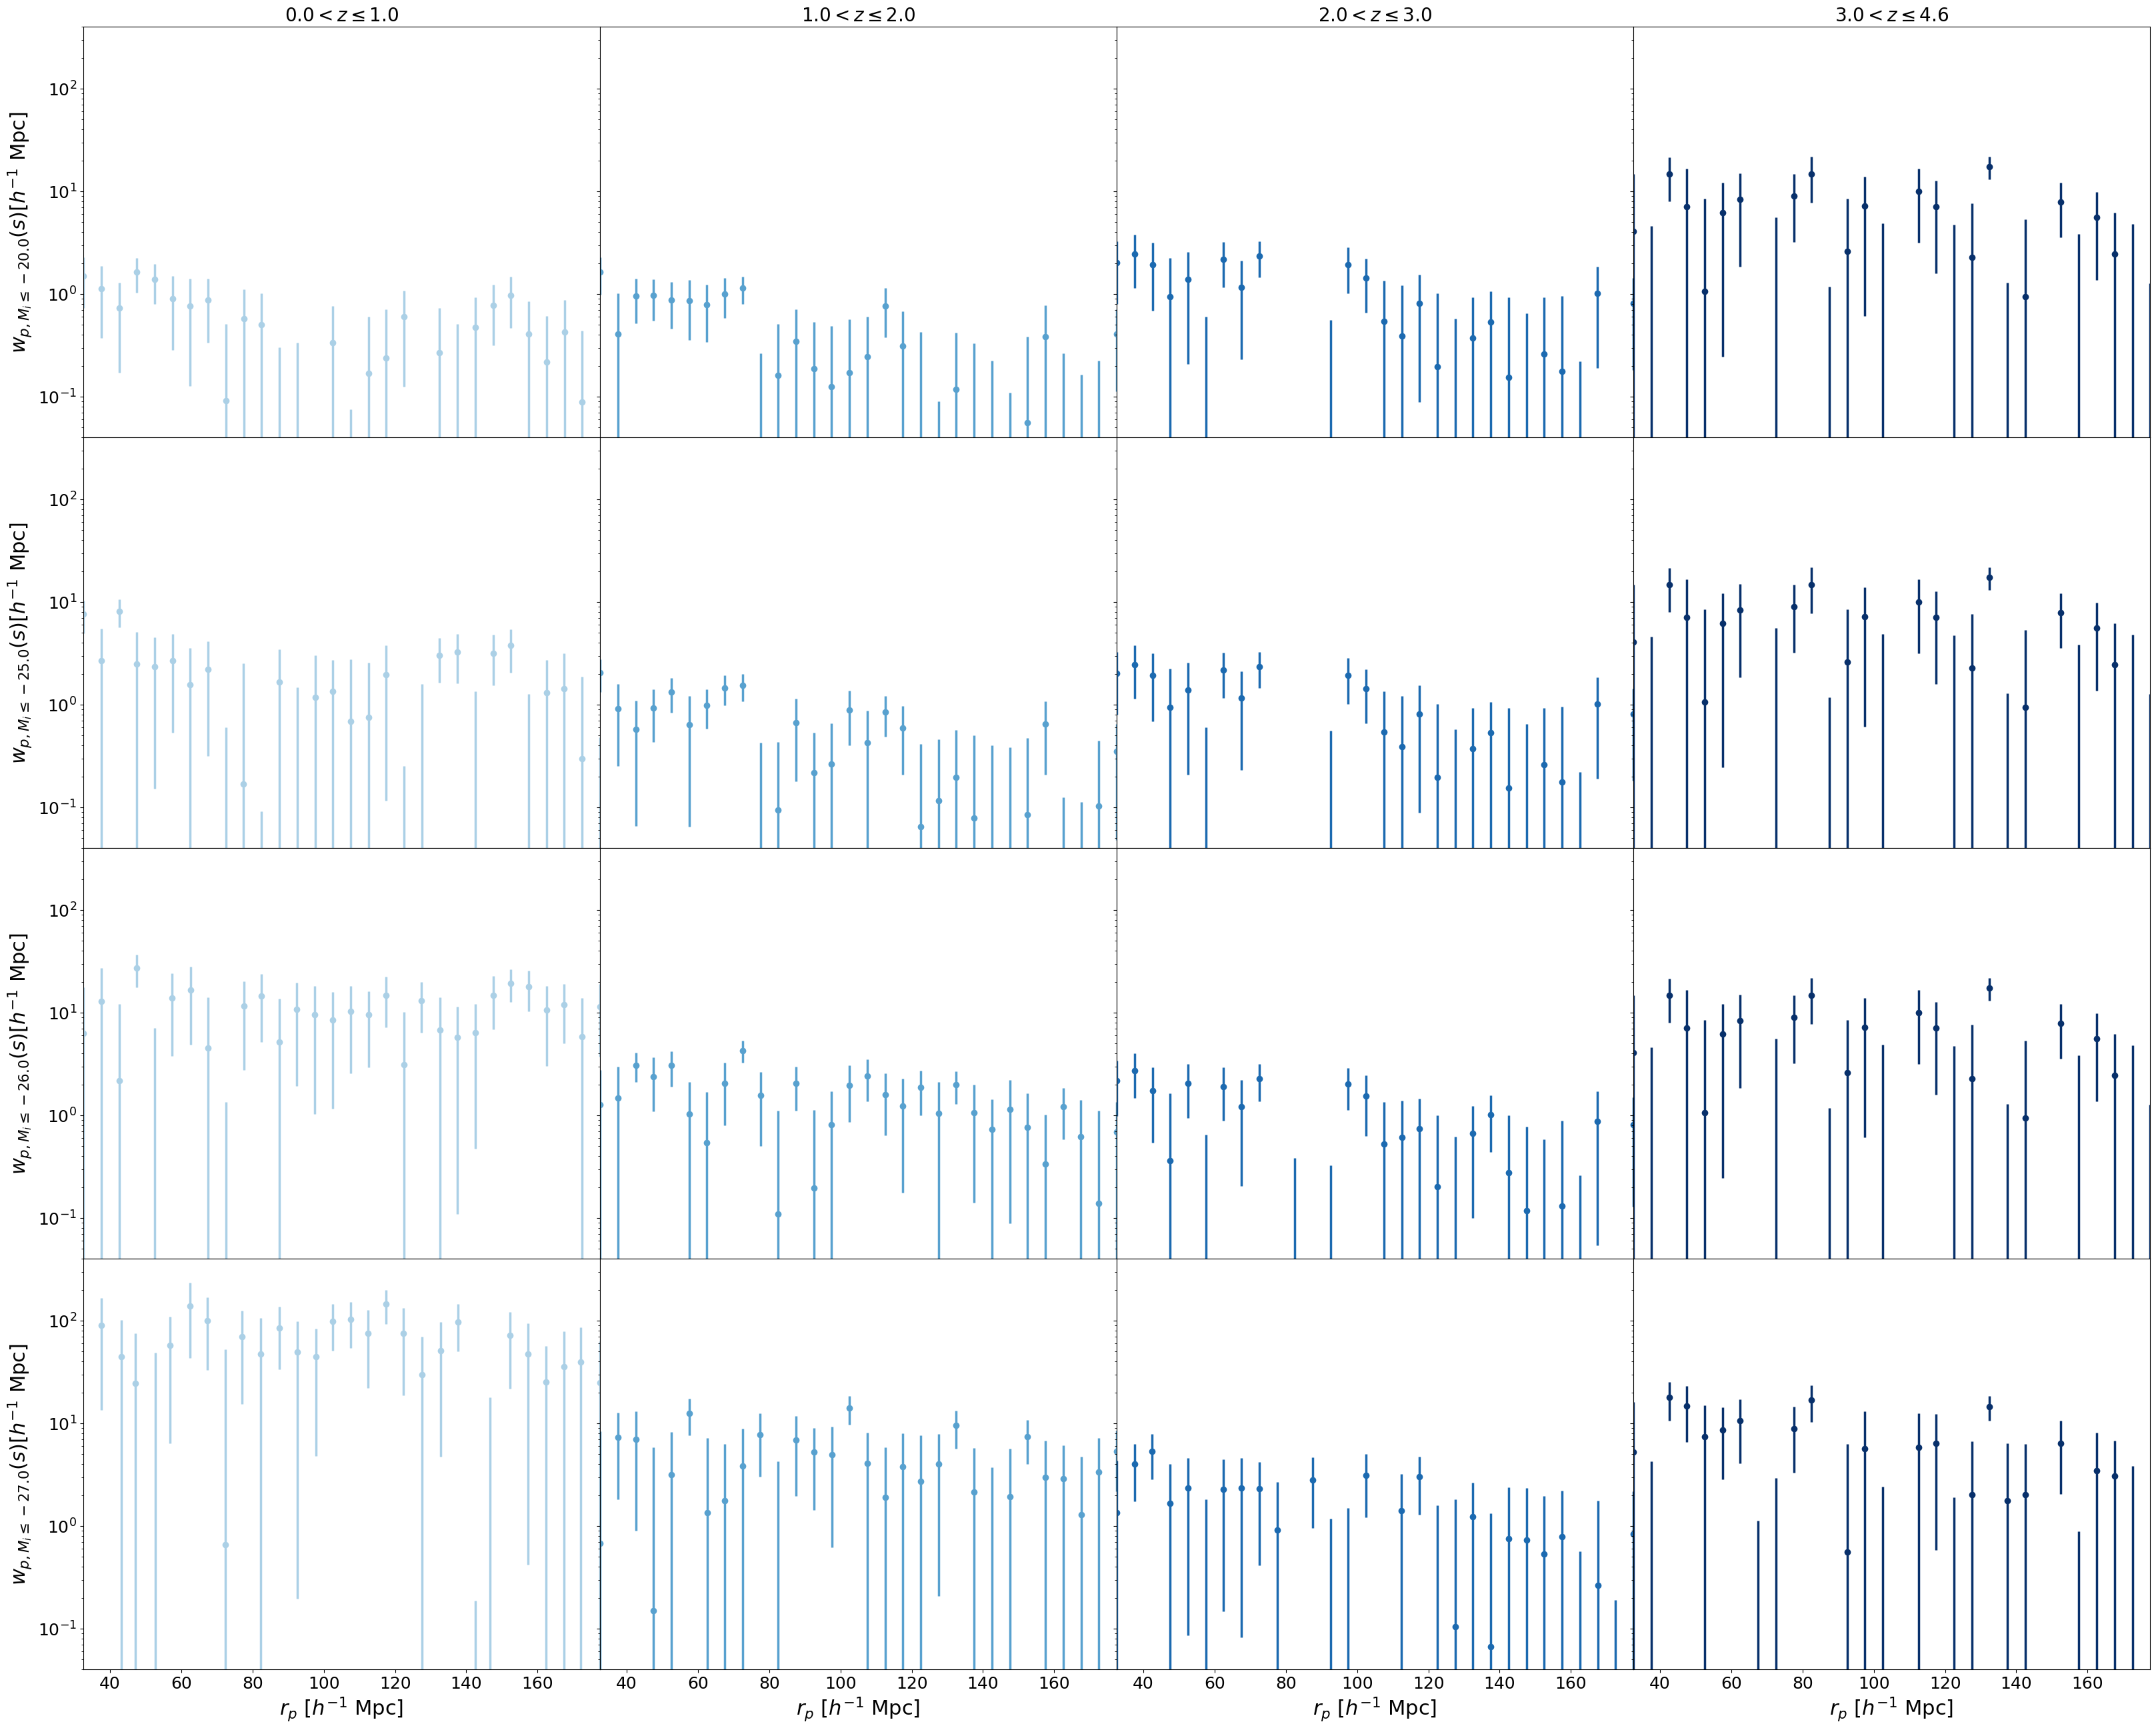

In [42]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)

for j in range(len(L_bins)):

    for i in range(len(zbin_array)-1):
        
        ax1 = fig.add_subplot(gs[j*4+i])

        sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(rpavg[L_bins[j]][i], wp[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
                 linewidth = 2.5, color = cmap_blue[i], yerr = sigma, linestyle = 'None')

        if j ==0:
            ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        ax1.set_ylim(4e-2, 4e2)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if i==0:
            ax1.set_ylabel(r"$w_{{p,M_i\leq{}}}(s) [h^{{-1}}$ Mpc]".format(L_bins[j]))
        else:
            ax1.set_yticklabels([])

plt.show()

## Plot correlation matrix

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/3804798635.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('$r_{{p,{:.1f}<z \leq{:.1f}}} (h^{{-1}}$ Mpc)'.format(zbin_array[i], zbin_array[i+1]))
/tmp/ipykernel_12267/3804798635.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)


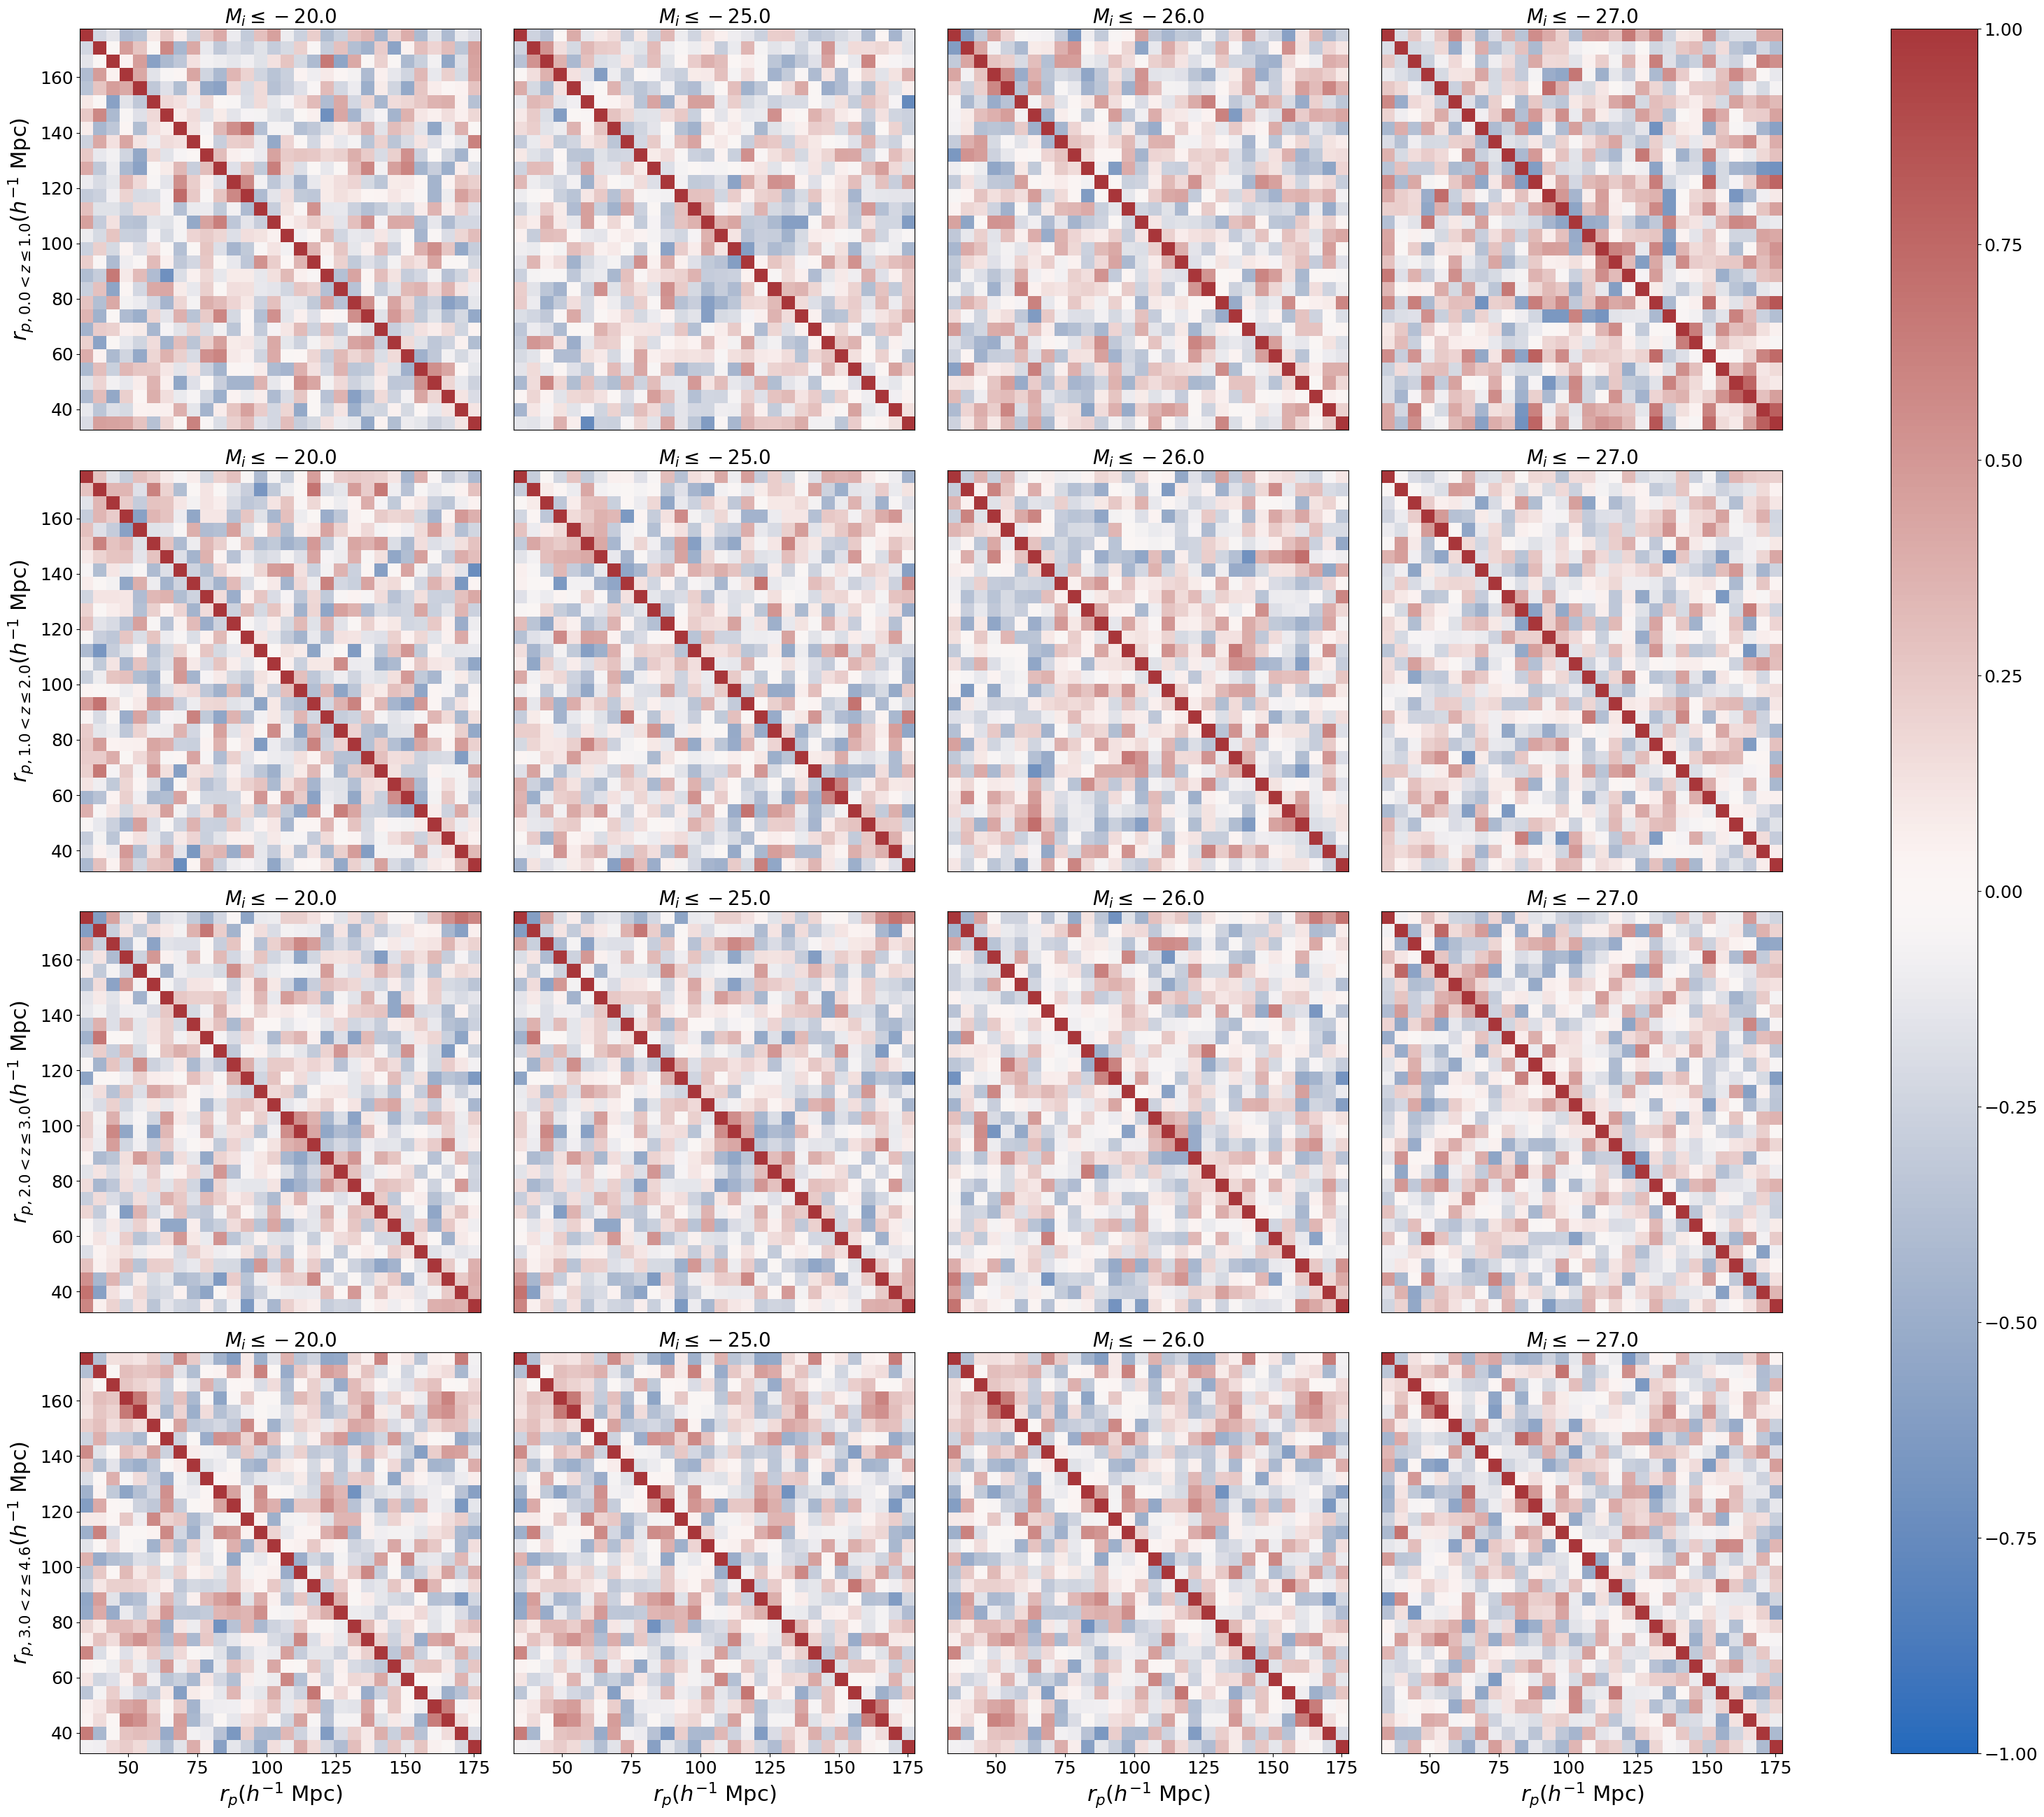

In [43]:
cmap = sns.color_palette("vlag", as_cmap=True)
r = quaia.recenter(rbins) #_chi2)

# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
axes = []
for i in range(len(zbin_array)-1):
    
    for j in range(len(L_bins)):
    
        ax1 = fig.add_subplot(gs[i*4+j])

        C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))
        matrix = np.corrcoef(C)
        image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
        print(image.get_clim())
        if i > 2:
            ax1.set_xlabel('$r_p (h^{-1}$ Mpc)')
        else:
            ax1.set_xticks([])
        if j == 0:
            ax1.set_ylabel('$r_{{p,{:.1f}<z \leq{:.1f}}} (h^{{-1}}$ Mpc)'.format(zbin_array[i], zbin_array[i+1]))
        else:
            ax1.set_yticks([])
        ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
        axes.append(ax1)
    
fig.colorbar(image, ax = axes)
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/712171006.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(r, np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[::-1][i])
/tmp/ipykernel_12267/712171006.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_12267/712171006.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]))


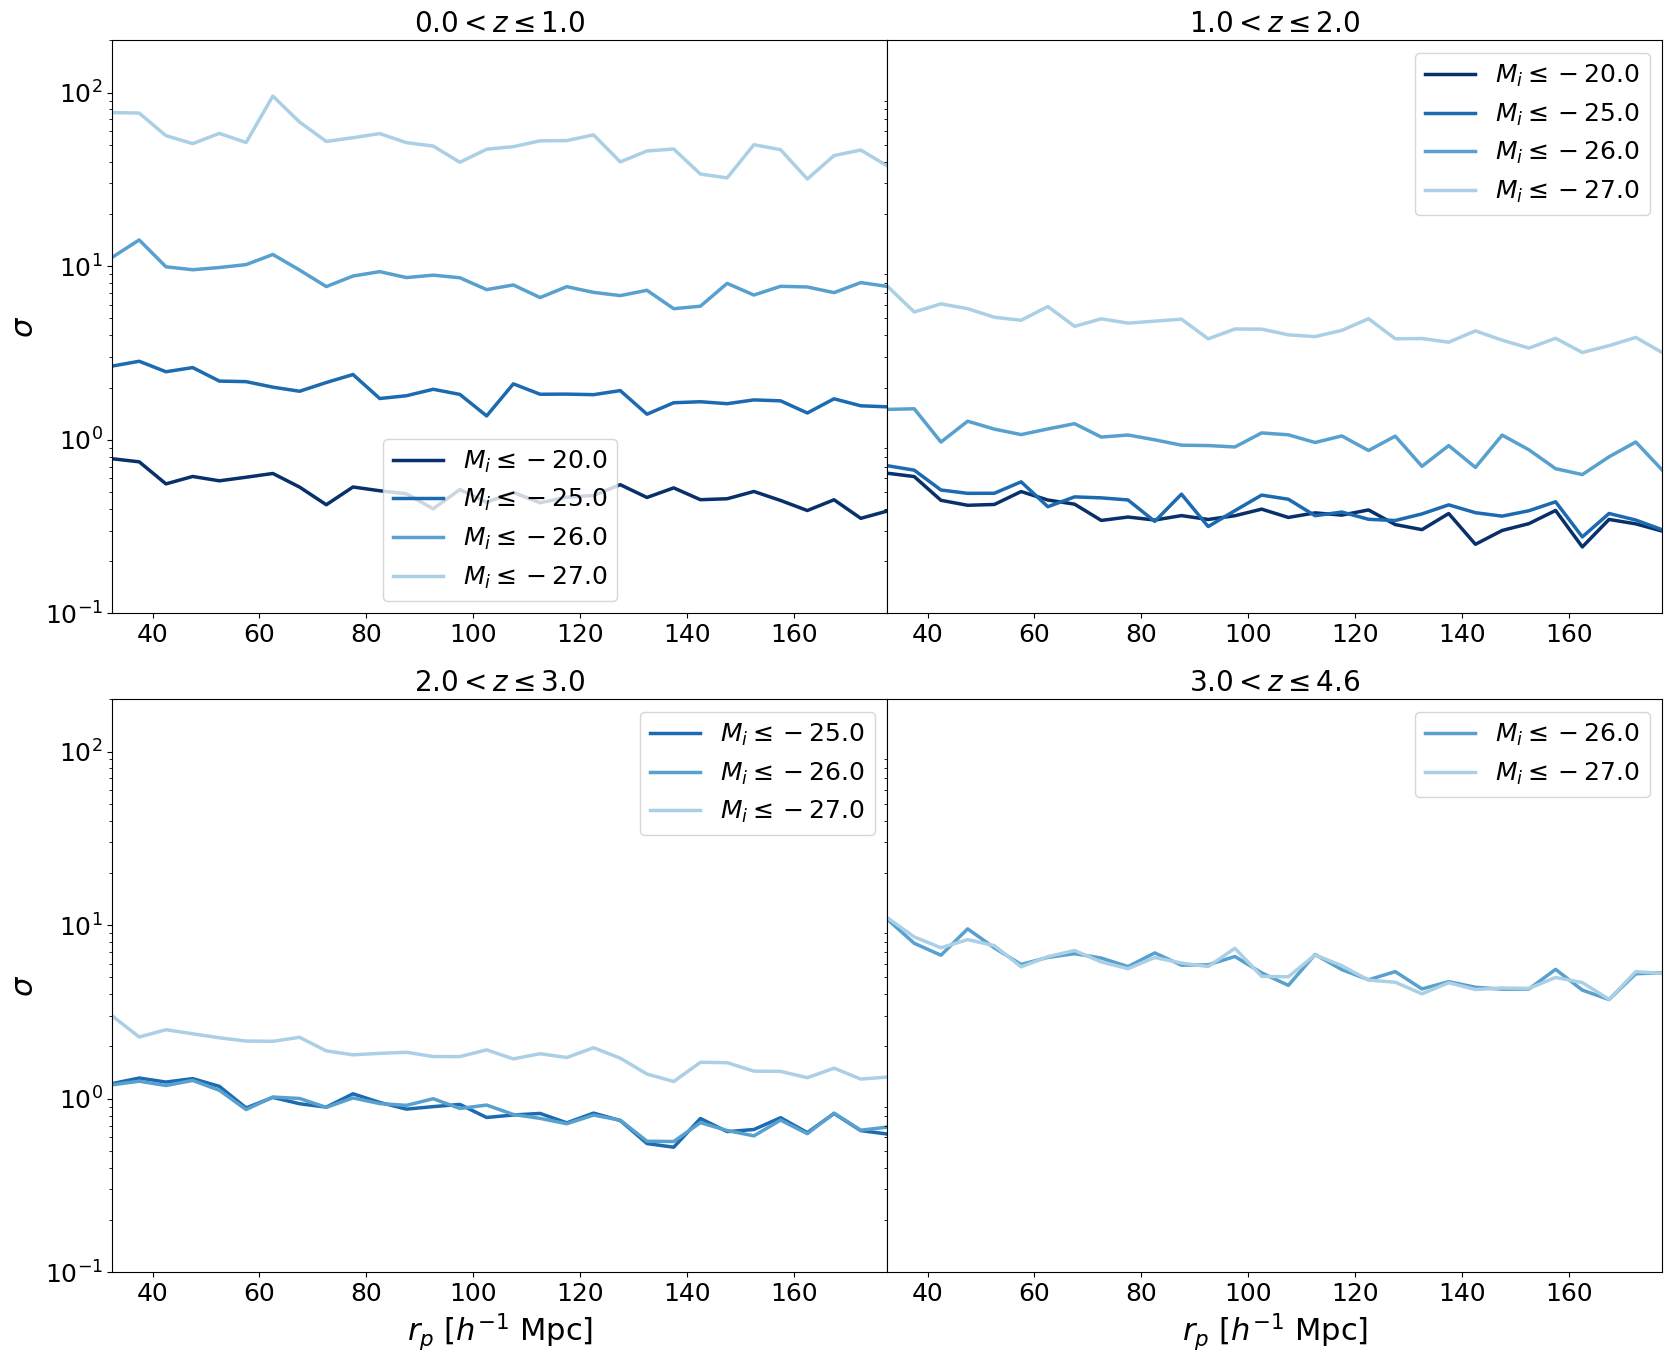

In [44]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in range(len(zbin_array)-1):

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[j], zbin_array[j+1], L_bins[i], N, cosmo)))
            ax1.plot(r, np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[::-1][i])

    ax1.set_xlim(r[0], r[-1])
    ax1.set_yscale('log')

    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-1, 2e2)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]))

    ax1.legend()

plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/1193341656.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(r, np.sqrt(var), linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]), color = cmap_blue[j])
/tmp/ipykernel_12267/1193341656.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_12267/1193341656.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))


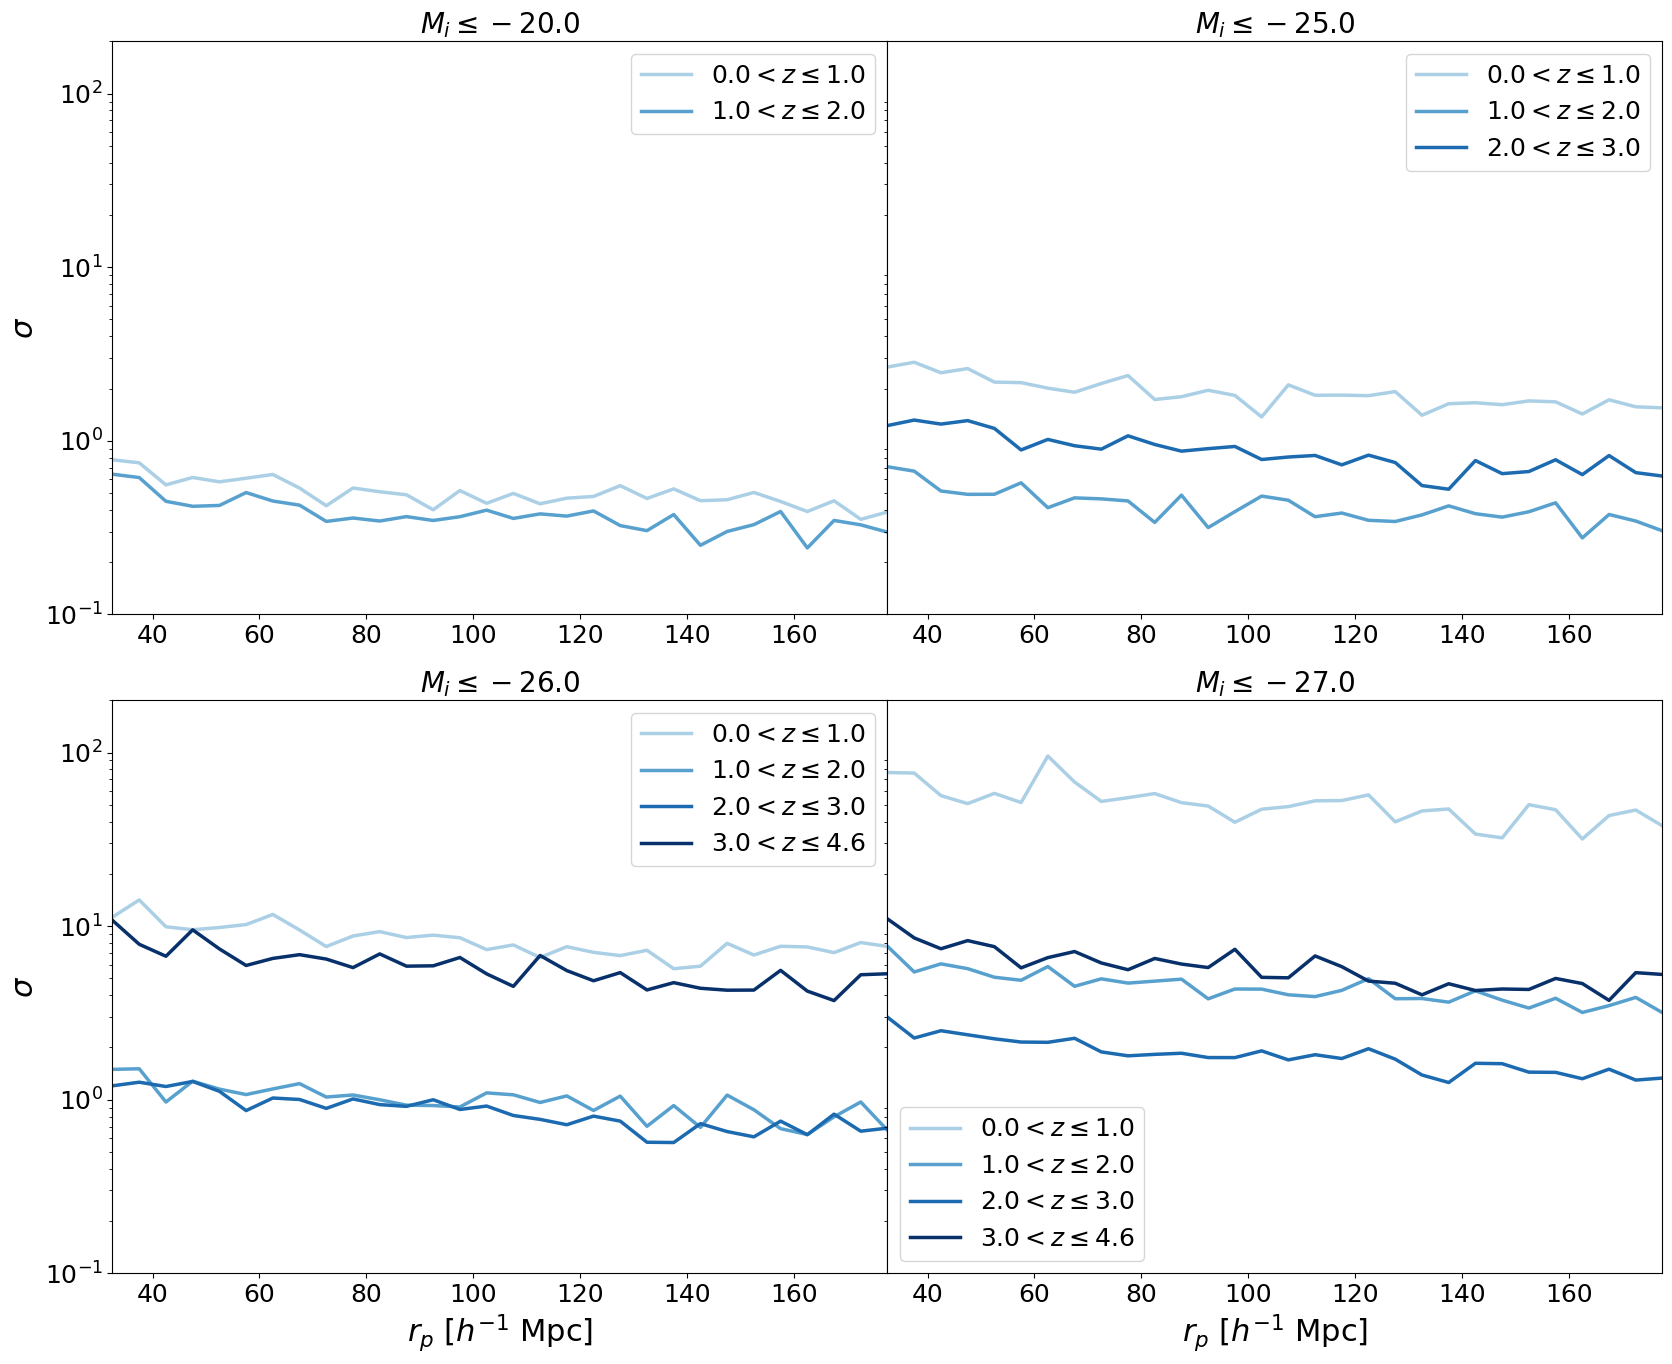

In [45]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(zbin_array)-1):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[j], zbin_array[j+1], L_bins[i], N, cosmo)))
            ax1.plot(r, np.sqrt(var), linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]), color = cmap_blue[j])

    ax1.set_xlim(r[0], r[-1])
    ax1.set_yscale('log')

    if i > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') #
            
    if i %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-1, 2e2)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    ax1.legend()
    
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/683311130.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(r, np.sqrt(var), linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]), color = cmap_blue[::-1][j])
/tmp/ipykernel_12267/683311130.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


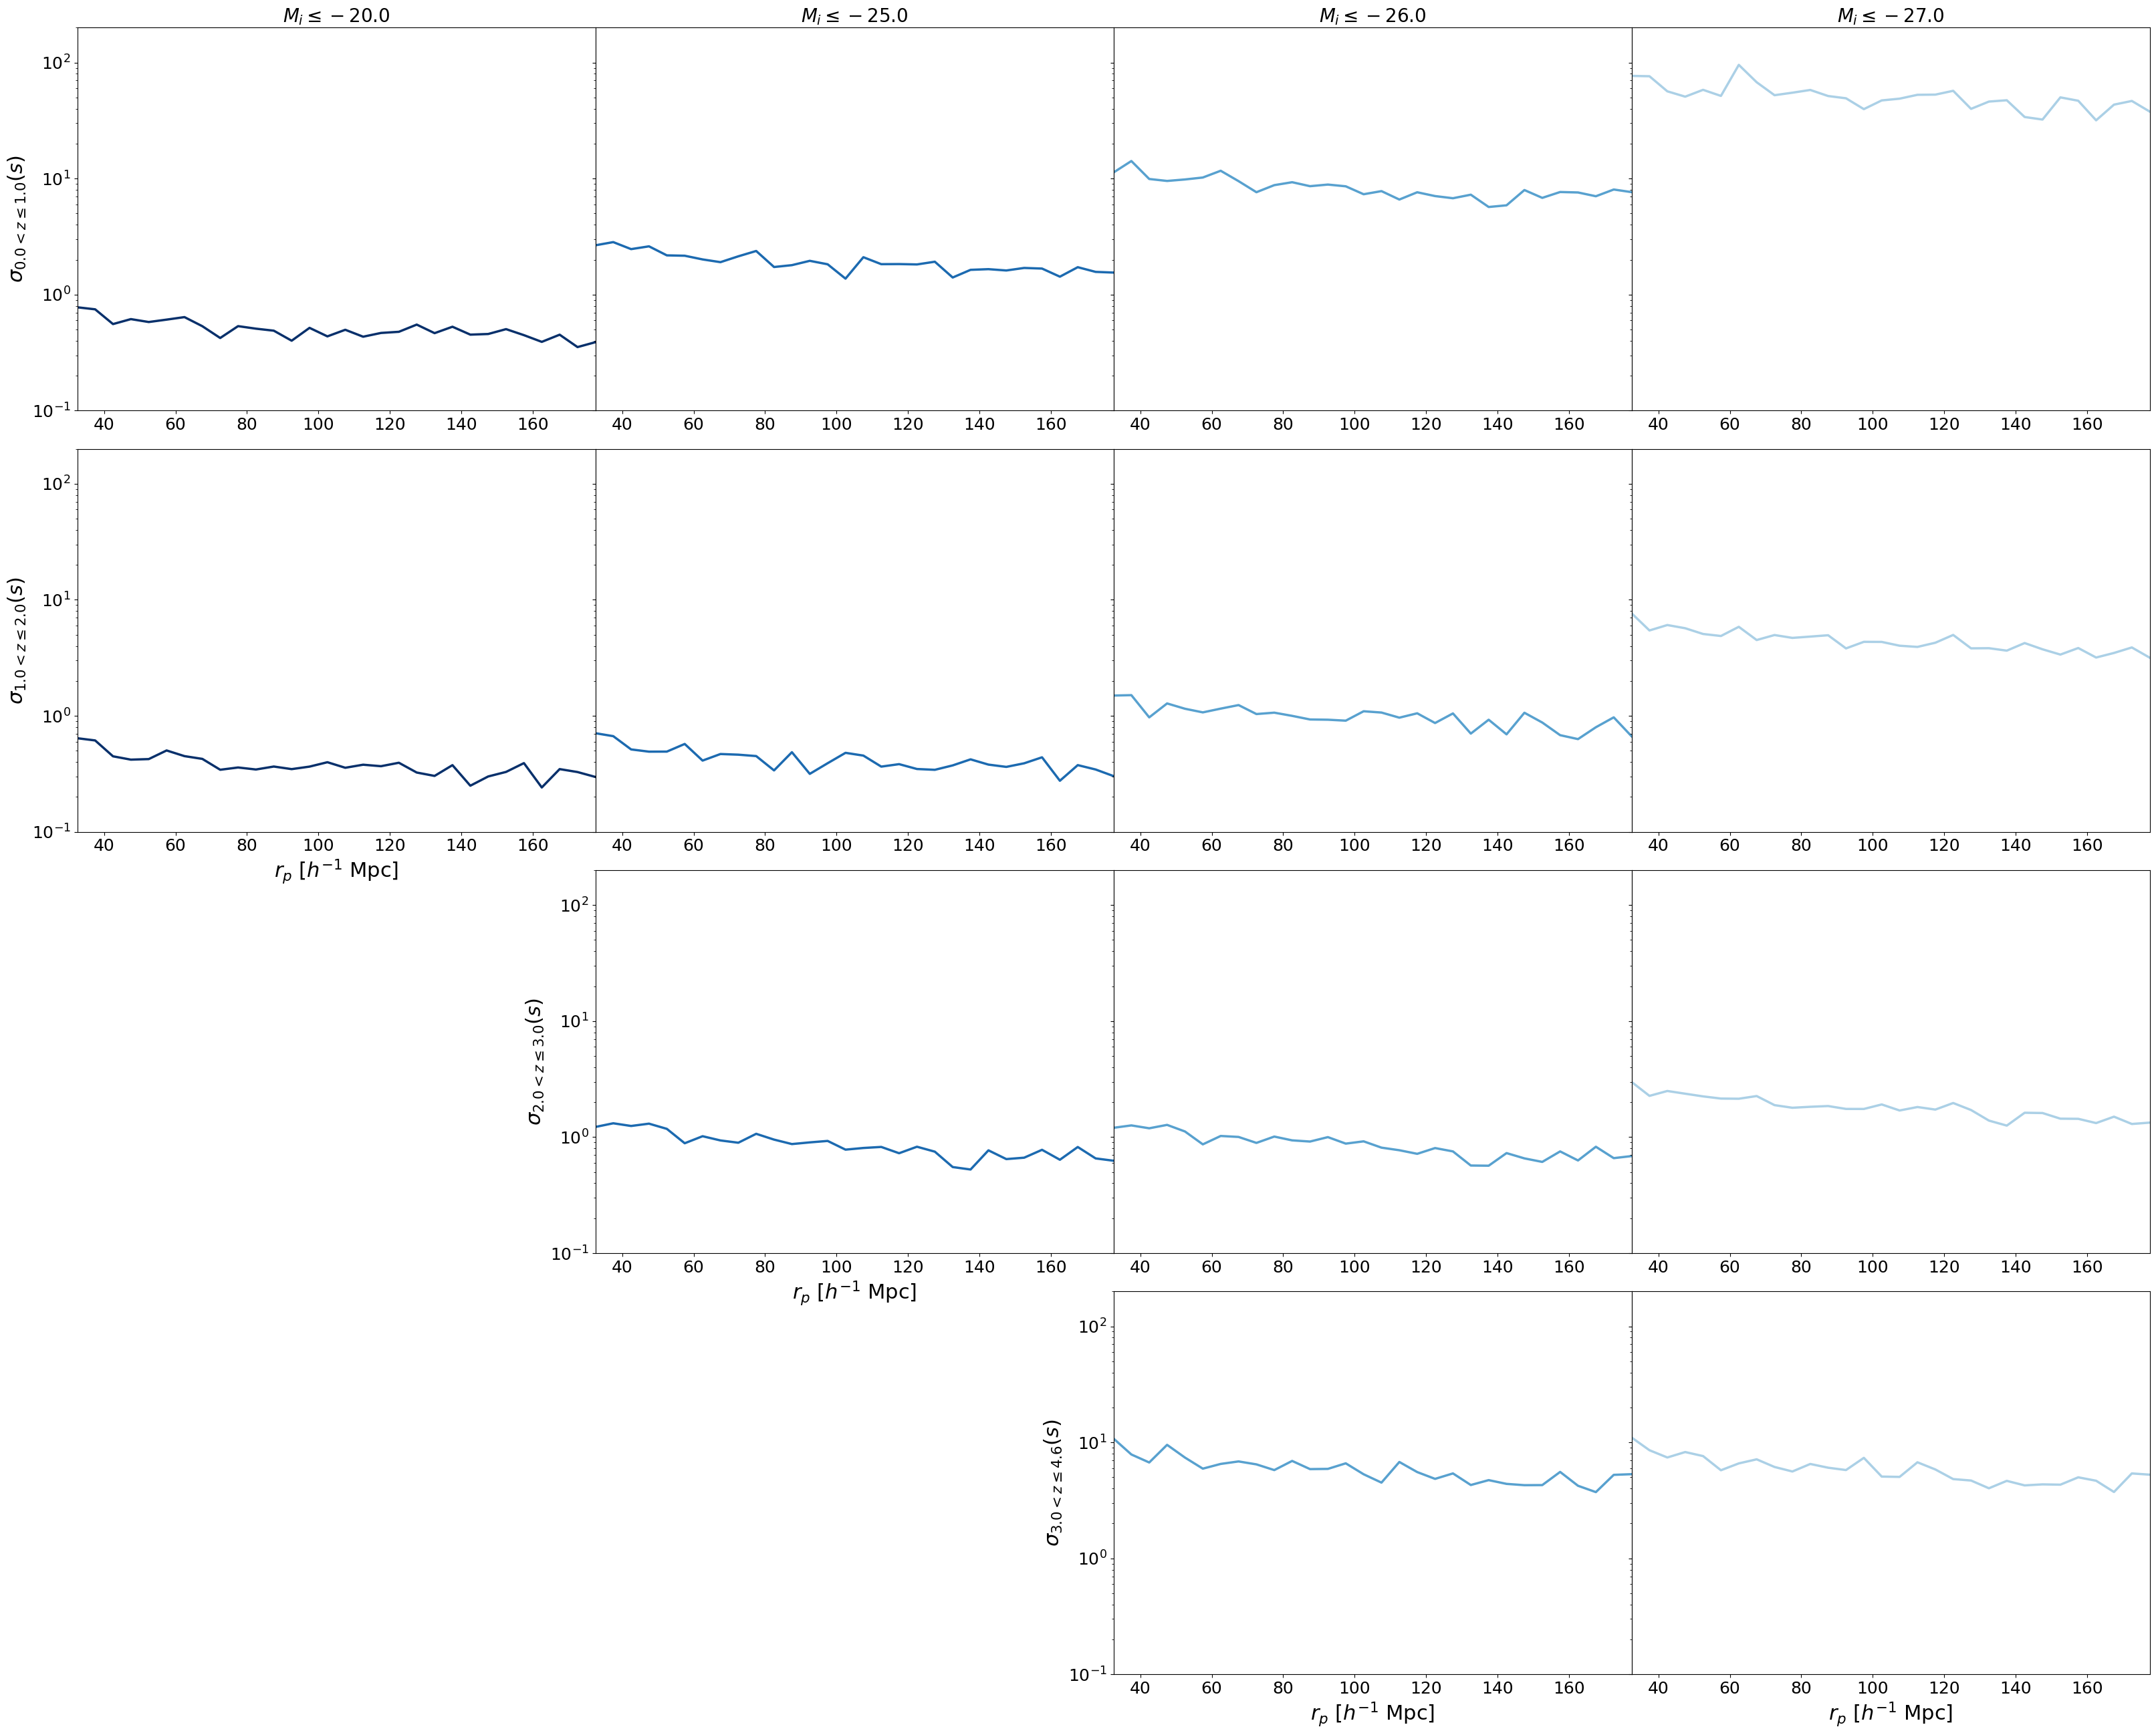

In [46]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
ymax = [0.8, 0.1, 0.1, 0.2]
for i in range(len(zbin_array)-1):
    
    for j in range(len(L_bins)):
    
        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[i*4+j])

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo)))
            ax1.plot(r, np.sqrt(var), linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]), color = cmap_blue[::-1][j])

            if i ==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(r[0], r[-1])
            ax1.set_ylim(1e-1, 2e2)
            if i > 2 or ((i>0) and (j <2) and (i!=j)):
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
            if j==0 or ((i>1) and (j <3) and (i!=j)):
                ax1.set_ylabel(r"$\sigma_{{{:.1f}<z \leq{:.1f}}}(s)$".format(zbin_array[i], zbin_array[i+1]))
            else:
                ax1.set_yticklabels([])

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12267/3114262404.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


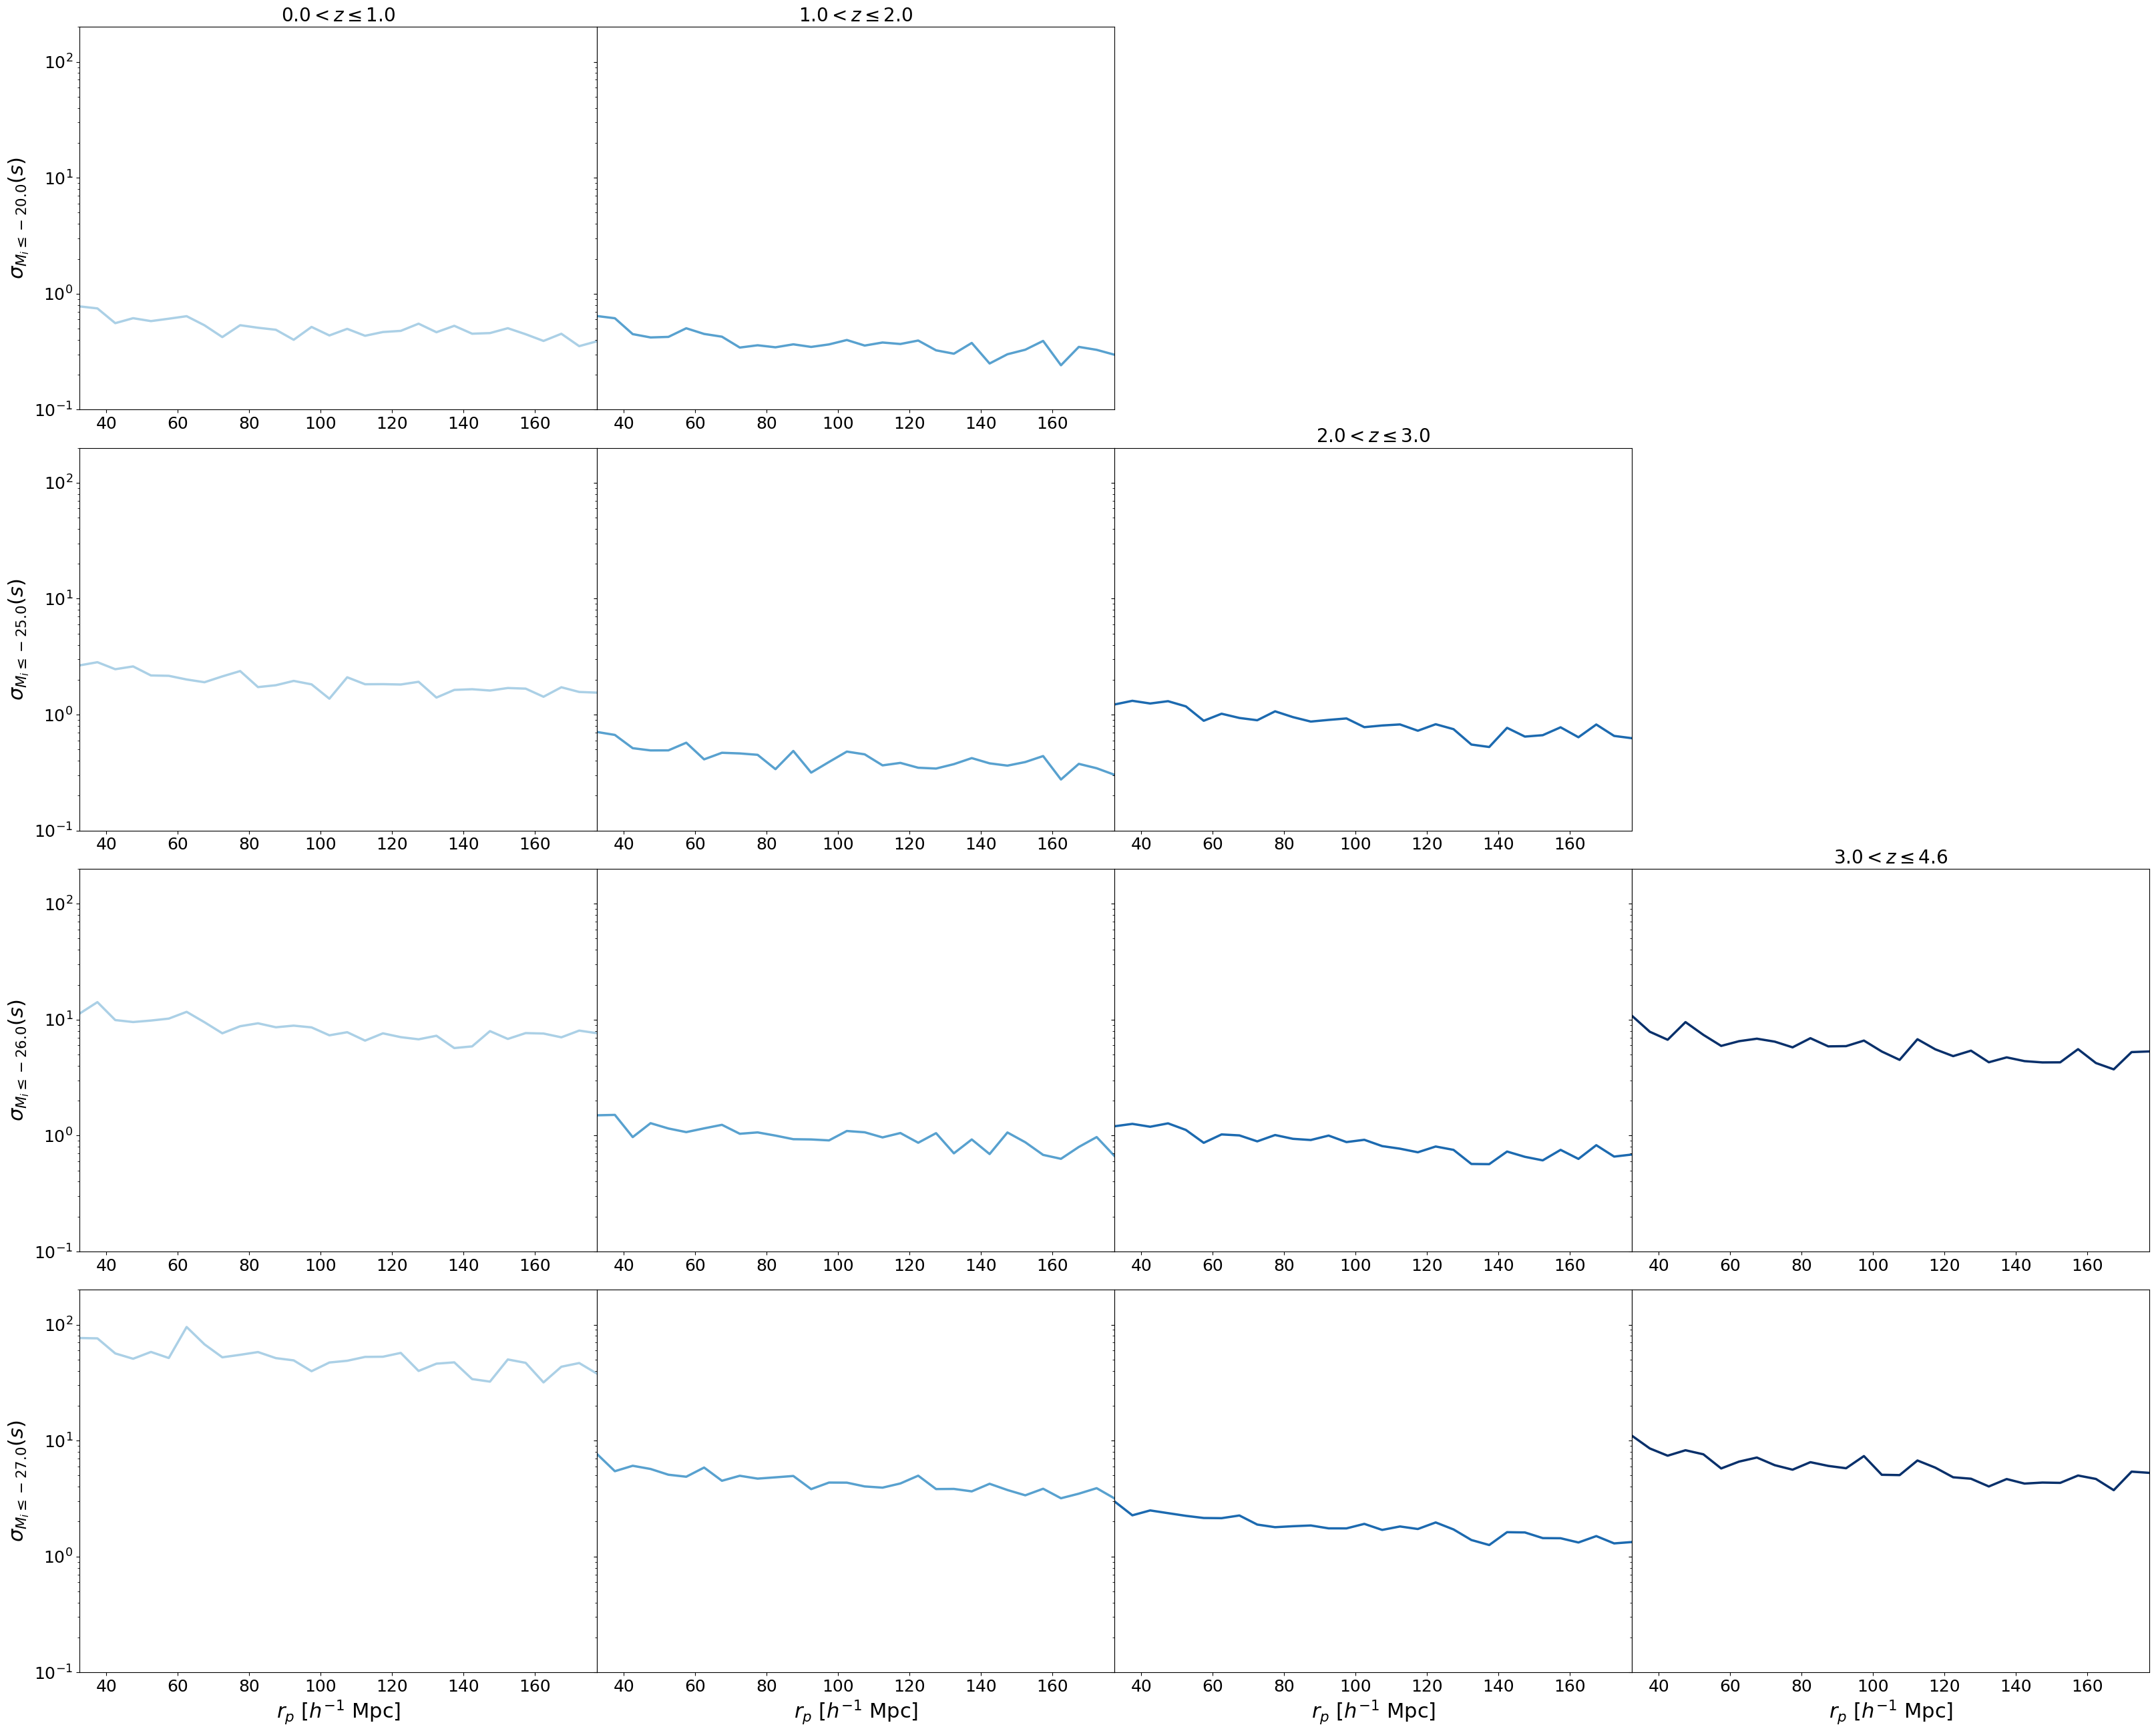

In [47]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for j in range(len(L_bins)):

    for i in range(len(zbin_array)-1):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[j*4+i])
    
            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo)))
            ax1.plot(r, np.sqrt(var), linewidth = 2.5, color = cmap_blue[i])
    
            if j ==0 or ((j<3) and (i>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(r[0], r[-1])
            ax1.set_ylim(1e-1, 2e2)
            if j > 2:
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
            if i==0:
                ax1.set_ylabel(r"$\sigma_{{M_i\leq{}}}(s)$".format(L_bins[j]))
            else:
                ax1.set_yticklabels([])

plt.show()